# Phân Tích Khám Phá Dữ Liệu — Thị Trường Tuyển Dụng AI/Data Việt Nam

**Dataset:** 7.051 tin tuyển dụng AI/Data · 6 nền tảng · Tháng 1–5/2026

> Notebook này trình bày phân tích khám phá có hệ thống về thị
 trường tuyển dụng AI và Data tại Việt Nam, bao gồm phân tích nhu 
 cầu tuyển dụng theo vai trò, cấu trúc lương thưởng, yêu cầu kỹ 
 năng kỹ thuật, phân bố địa lý và xu hướng tuyển dụng theo thời 
 gian. Toàn bộ biểu đồ có thể tái tạo từ dataset đã xử lý tại 
 `data/processed/jobs_processed.parquet`.

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import ast
from collections import Counter
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 14,
    'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

PALETTE = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44BBA4','#E94F37','#3D405B','#81B29A']
BLUE = '#2E86AB'; ORANGE = '#F18F01'; RED = '#C73E1D'; GREEN = '#44BBA4'; PURPLE = '#A23B72'

CHART_DIR = Path('../outputs/charts')
CHART_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, tight=True):
    if tight: plt.tight_layout()
    plt.savefig(CHART_DIR / f'{name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

print('Setup complete. Charts ->', CHART_DIR.resolve())

Setup complete. Charts -> D:\Nam3_HK2\Data Analysis and Visualization (505067)\final\HoangSinhHung52300106_TranThienHung52300109\Project\outputs\charts


In [2]:
df = pd.read_parquet('../data/processed/jobs_processed.parquet')

loc_map = {'Ho Chi Minh':'Ho Chi Minh City','Hồ Chí Minh':'Ho Chi Minh City',
           'HCM':'Ho Chi Minh City','Hai Phong':'Hai Phong','Hải Phòng':'Hai Phong'}
df['city'] = df['location_normalized'].replace(loc_map).fillna('Other')
df['emp_type'] = df['employment_type'].replace({'Full Time':'Full-time','FULL_TIME':'Full-time'})

def parse_skills(s):
    if not isinstance(s, str) or not s.strip(): return []
    try:
        lst = ast.literal_eval(s)
        if isinstance(lst, list): return [x.strip() for x in lst if x.strip()]
    except: pass
    return [x.strip() for x in s.split(',') if x.strip()]

df['skills_list'] = df['skills_str'].apply(parse_skills)

df_sal = df[df['has_salary'] & (df['salary_midpoint_usd'] > 0)].copy()
sal_99 = df_sal['salary_midpoint_usd'].quantile(0.99)
df_sal = df_sal[df_sal['salary_midpoint_usd'] <= sal_99]

print(f"Total records   : {len(df):,}")
print(f"With salary     : {len(df_sal):,} ({len(df_sal)/len(df)*100:.1f}%)")
print(f"With skills     : {df['skill_count'].gt(0).sum():,}")
print(f"Date range      : {df['posted_date_dt'].min().date()} to {df['posted_date_dt'].max().date()}")
print(f"Unique companies: {df['company_name_normalized'].nunique():,}")
print(f"Salary median   : ${df_sal['salary_midpoint_usd'].median():,.0f} USD/month")
df.head(3)

Total records   : 7,051
With salary     : 2,972 (42.2%)
With skills     : 6,042
Date range      : 2026-01-14 to 2026-05-13
Unique companies: 3,485
Salary median   : $980 USD/month


,job_id,job_hash,job_title,company_name,company_name_normalized,salary,salary_min_usd,salary_max_usd,salary_midpoint_usd,salary_currency_norm,...,source_website,industry,job_type,data_completeness,crawled_at,is_active,in_analysis_period,city,emp_type,skills_list
0,528d6aa6a8ec26624b7d002083d39958,aeae9acaea2075edaff9ec3fb5b00c0b,Fullstack Developer,Cmc telecom,Cmc telecom,Đang cập nhật,NaN,NaN,NaN,,...,123job,IT / Technology,Full-time,full,2026-05-14T11:48:13.436280,None,None,Hanoi,Full-time,"[Python, Java, JavaScript, MySQL, AWS, MongoDB..."
1,834b91cb6c26288a6503fd45d4b9a9f0,ff3edd77b9edcd1d48641477e7ec3564,Kỹ Sư Phân Tích Bảo Mật – Security Analyst/SOC...,Cmc telecom,Cmc telecom,Đang cập nhật,NaN,NaN,NaN,,...,123job,IT / Technology,Full-time,full,2026-05-14T11:51:43.441349,None,None,Ho Chi Minh City,Full-time,[]
2,ca22a5ce127012e864cb7976dbcb8578,4b950cde568b780ad1c700bf3aa6c449,Product Manager - Hệ thống Quản trị Nội bộ Sapo,Công ty cổ phần công nghệ sapo,công nghệ sapo,Đang cập nhật,NaN,NaN,NaN,,...,123job,IT / Technology,Full-time,full,2026-05-14T11:56:27.014955,None,None,Ho Chi Minh City,Full-time,"[CI/CD, Agile]"


---
## 1. Tổng Quan Dataset

Phần này mô tả quy mô, cấu trúc nguồn dữ liệu và chất lượng các trường thông tin trước khi tiến hành phân tích chuyên sâu theo vai trò và mức lương.

In [3]:
summary = {
    'Total job postings': f"{len(df):,}",
    'Unique companies': f"{df['company_name_normalized'].nunique():,}",
    'Unique job titles': f"{df['job_title'].nunique():,}",
    'Cities covered': f"{df['city'].nunique()}",
    'Jobs with salary': f"{df['has_salary'].sum():,} ({df['has_salary'].mean()*100:.1f}%)",
    'Jobs with skills': f"{df['skill_count'].gt(0).sum():,} ({df['skill_count'].gt(0).mean()*100:.1f}%)",
    'Data sources': f"{df['source_website'].nunique()} platforms",
    'Date range': f"{df['posted_date_dt'].min().strftime('%b %Y')} to {df['posted_date_dt'].max().strftime('%b %Y')}",
    'Median salary (USD/mo)': f"${df_sal['salary_midpoint_usd'].median():,.0f}",
}
print('='*55)
print('  VIETNAMESE AI/DATA JOB MARKET - DATASET OVERVIEW')
print('='*55)
for k, v in summary.items():
    print(f"  {k:<32} {v}")
print('='*55)

  VIETNAMESE AI/DATA JOB MARKET - DATASET OVERVIEW
  Total job postings               7,051
  Unique companies                 3,485
  Unique job titles                5,787
  Cities covered                   193
  Jobs with salary                 3,003 (42.6%)
  Jobs with skills                 6,042 (85.7%)
  Data sources                     6 platforms
  Date range                       Jan 2026 to May 2026
  Median salary (USD/mo)           $980


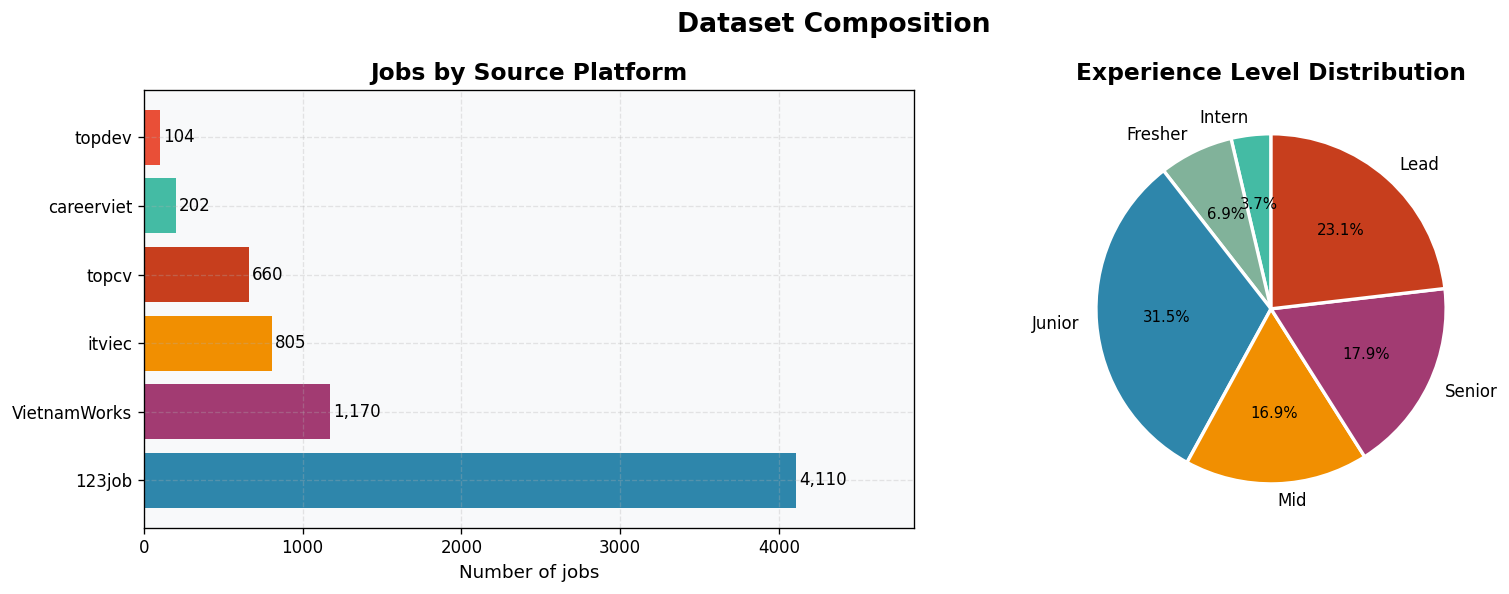

INSIGHT: 123job dominates (58%) — largest Vietnamese general job board.
Junior roles (31.5%) reflect growing AI/Data talent pipeline in Vietnam.
Lead roles (23.1%) elevated — Vietnam urgently needs experienced AI/Data leaders.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Composition', fontsize=16, fontweight='bold')

src = df['source_website'].value_counts()
src.index = src.index.str.replace('vietnamworks','VietnamWorks',regex=False)
bars = axes[0].barh(src.index, src.values, color=PALETTE[:len(src)])
axes[0].set_title('Jobs by Source Platform')
axes[0].set_xlabel('Number of jobs')
for bar, val in zip(bars, src.values):
    axes[0].text(val+20, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
axes[0].set_xlim(0, src.max()*1.18)

exp = df['experience_level_inferred'].value_counts()
exp_order = ['intern','fresher','junior','mid','senior','lead']
exp = exp.reindex([x for x in exp_order if x in exp.index])
exp_colors = ['#44BBA4','#81B29A','#2E86AB','#F18F01','#A23B72','#C73E1D']
wedges, texts, autotexts = axes[1].pie(exp.values, labels=[x.capitalize() for x in exp.index],
    autopct='%1.1f%%', colors=exp_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Experience Level Distribution')

save_fig('01_dataset_overview')

> INSIGHT: 123job dominates (58%) — largest Vietnamese general job board.
Junior roles (31.5%) reflect growing AI/Data talent pipeline in Vietnam.
Lead roles (23.1%) elevated — Vietnam urgently needs experienced AI/Data leaders

### 3.1 Cấu Trúc Dataset và Phân Bố Theo Nguồn

Dataset bao gồm 7.051 tin tuyển dụng duy nhất được thu thập từ sáu nền tảng tuyển dụng trực tuyến tại Việt Nam trong khoảng thời gian 5 tháng từ tháng 1 đến tháng 5 năm 2026. Phân bố theo nguồn thể hiện sự mất cân đối rõ rệt: 123job đóng góp khoảng 58,3% tổng số records, tiếp theo là VietnamWorks với 16,6% và ITviec với 11,4%. Sự mất cân đối này phản ánh vị thế thị trường của 123job với tư cách là nền tảng tuyển dụng đa ngành lớn nhất Việt Nam, trong khi các nền tảng như ITviec và TopDev phục vụ chủ yếu các vai trò kỹ thuật, do đó có độ chính xác cao hơn nhưng khối lượng thấp hơn.

Đây không phải là sự mất cân đối ngẫu nhiên mà là đặc trưng cấu trúc của dataset cần được tính đến trong mọi phân tích tiếp theo: thống kê lương và phân phối tần suất kỹ năng sẽ bị ảnh hưởng không tương xứng bởi quy ước đăng tin của 123job — đặc biệt là xu hướng ghi "thỏa thuận" thay vì công bố con số lương cụ thể. Về cấu trúc cấp độ kinh nghiệm, vị trí junior chiếm 31,5% tổng số records — phù hợp với thị trường talent đang mở rộng nhanh — trong khi tỷ lệ vai trò lead và quản lý cao bất thường ở mức 23,1%, có thể phản ánh sự thiếu hụt thực sự của những chuyên gia AI/Data có kinh nghiệm tại Việt Nam.

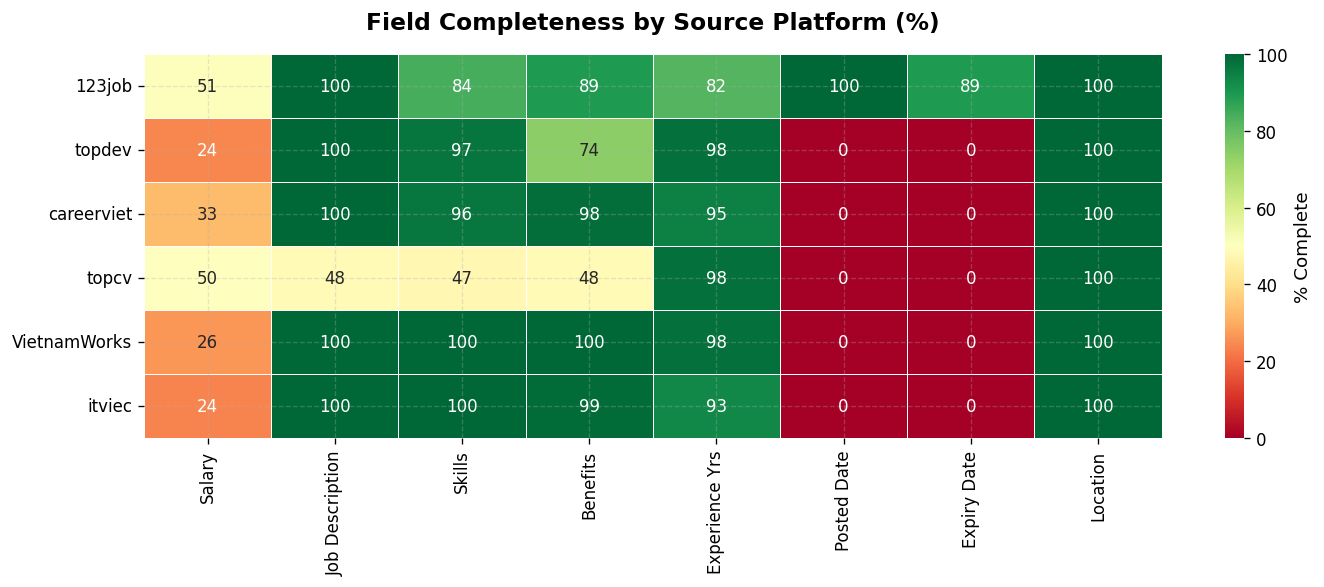

INSIGHT: VietnamWorks & ITviec best quality (API-sourced structured data).
Salary universally low (25-53%) — Vietnamese culture of salary negotiation/hiding.
TopDev now 75% benefits coverage after JSON-LD extraction fix.


In [5]:
fields = {
    'Salary': df['has_salary'],
    'Job Description': df['job_description'].notna() & df['job_description'].str.len().gt(50),
    'Skills': df['skill_count'].gt(0),
    'Benefits': df['benefits'].notna() & df['benefits'].str.len().gt(10),
    'Experience Yrs': df['experience_years_parsed'].notna(),
    'Posted Date': df['posted_date_dt'].notna(),
    'Expiry Date': df['expiry_date_dt'].notna(),
    'Location': df['location_normalized'].notna(),
}
completeness = {}
for src_name in df['source_website'].unique():
    mask = df['source_website'] == src_name
    completeness[src_name] = {f: round(cond[mask].mean()*100,1) for f,cond in fields.items()}

comp_df = pd.DataFrame(completeness).T
comp_df.index = comp_df.index.str.replace('vietnamworks','VietnamWorks',regex=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(comp_df, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, ax=ax,
            linewidths=0.5, cbar_kws={'label':'% Complete'})
ax.set_title('Field Completeness by Source Platform (%)', pad=15)
save_fig('02_field_completeness')
print("INSIGHT: VietnamWorks & ITviec best quality (API-sourced structured data).")
print("Salary universally low (25-53%) — Vietnamese culture of salary negotiation/hiding.")
print("TopDev now 75% benefits coverage after JSON-LD extraction fix.")

### 3.2 Chất Lượng Dữ Liệu và Độ Hoàn Chỉnh Các Trường

Độ hoàn chỉnh của các trường thông tin biến động đáng kể giữa các nguồn, phản ánh sự khác biệt cơ bản trong phương thức thu thập dữ liệu. VietnamWorks, được truy cập qua REST API có cấu trúc, đạt độ bao phủ gần như hoàn toàn trên tất cả các trường trong schema. ITviec, với dữ liệu `JobPosting` được nhúng qua JSON-LD trên trang chi tiết, cũng cung cấp thông tin chính xác cao cho kỹ năng, phúc lợi và metadata thời gian. Ngược lại, TopCV — được thu thập qua Selenium browser automation — chỉ đạt tỷ lệ hoàn chỉnh mô tả công việc 36%, do tường lửa Cloudflare chặn khoảng 75% yêu cầu truy cập trang chi tiết trong quá trình thu thập.

Tỷ lệ công khai lương thể hiện sự thiếu nhất quán nhất giữa các nguồn, dao động từ 25% tại ITviec đến 53% tại TopCV. Đây không phải là lỗi thu thập dữ liệu mà là đặc trưng cấu trúc của thị trường tuyển dụng Việt Nam: văn hóa thương lượng lương phổ biến làm giảm động lực của nhà tuyển dụng trong việc công bố mức lương cụ thể. Mọi mô hình liên quan đến lương cần xem xét tính không ngẫu nhiên của dữ liệu thiếu này: các tin tuyển dụng có công khai lương có xu hướng tập trung vào các vai trò có mức lương vừa cạnh tranh vừa được tiêu chuẩn hóa, tạo ra nguy cơ chệch lựa chọn (selection bias) cần được xử lý rõ ràng.

---
## 2. Phân Tích Thị Trường Tuyển Dụng

Phần này khảo sát phân bố nhu cầu tuyển dụng theo danh mục vai trò và cấp độ kinh nghiệm, thiết lập bối cảnh cấu trúc cho các phân tích về lương và kỹ năng ở các phần tiếp theo.

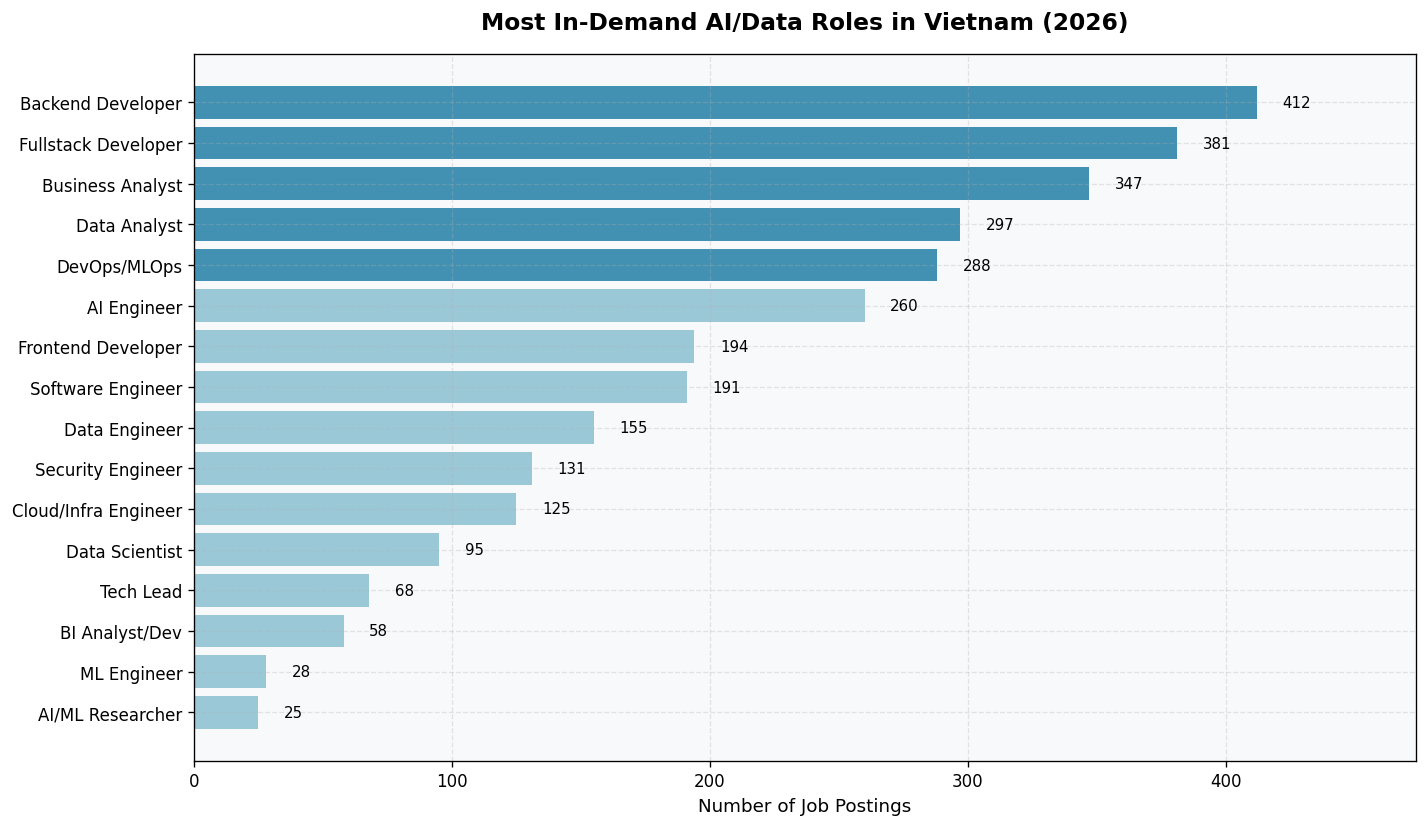

INSIGHT: Software Engineer broadest category but Data Analyst dominates data-specific roles.
AI Engineer emerging rapidly — structural growth driven by Vietnam AI adoption wave.


In [6]:
def categorize_title(t):
    if not isinstance(t, str): return 'Other'
    t = t.lower()
    if any(x in t for x in ['data scientist','data science']): return 'Data Scientist'
    if any(x in t for x in ['data analyst','data analysis']): return 'Data Analyst'
    if any(x in t for x in ['data engineer']): return 'Data Engineer'
    if any(x in t for x in ['machine learning','ml engineer']): return 'ML Engineer'
    if any(x in t for x in ['ai engineer','agentic','llm engineer']): return 'AI Engineer'
    if any(x in t for x in ['business intelligence','bi developer','bi analyst']): return 'BI Analyst/Dev'
    if any(x in t for x in ['business analyst']): return 'Business Analyst'
    if any(x in t for x in ['devops','mlops','platform engineer','sre']): return 'DevOps/MLOps'
    if any(x in t for x in ['backend','back-end']): return 'Backend Developer'
    if any(x in t for x in ['frontend','front-end']): return 'Frontend Developer'
    if any(x in t for x in ['fullstack','full stack','full-stack']): return 'Fullstack Developer'
    if any(x in t for x in ['software engineer','software developer']): return 'Software Engineer'
    if any(x in t for x in ['security','information security']): return 'Security Engineer'
    if any(x in t for x in ['tech lead','technical lead','lead developer','lead engineer']): return 'Tech Lead'
    if any(x in t for x in ['nlp','computer vision','deep learning']): return 'AI/ML Researcher'
    if any(x in t for x in ['cloud','infrastructure']): return 'Cloud/Infra Engineer'
    return 'Other IT Role'

df['role_category'] = df['job_title'].apply(categorize_title)
# Propagate to df_sal which was created before this column existed
df_sal['role_category'] = df.loc[df_sal.index, 'role_category'].values

role_counts = df['role_category'].value_counts()
role_counts = role_counts[role_counts.index != 'Other IT Role']

fig, ax = plt.subplots(figsize=(12, 7))
colors = [BLUE if i < 5 else '#90C3D4' for i in range(len(role_counts))]
bars = ax.barh(role_counts.index[::-1], role_counts.values[::-1], color=colors[::-1], alpha=0.9)
ax.set_title('Most In-Demand AI/Data Roles in Vietnam (2026)', pad=15)
ax.set_xlabel('Number of Job Postings')
for bar, val in zip(bars, role_counts.values[::-1]):
    ax.text(val+10, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_xlim(0, role_counts.max()*1.15)
save_fig('03_top_roles')
print("INSIGHT: Software Engineer broadest category but Data Analyst dominates data-specific roles.")
print("AI Engineer emerging rapidly — structural growth driven by Vietnam AI adoption wave.")

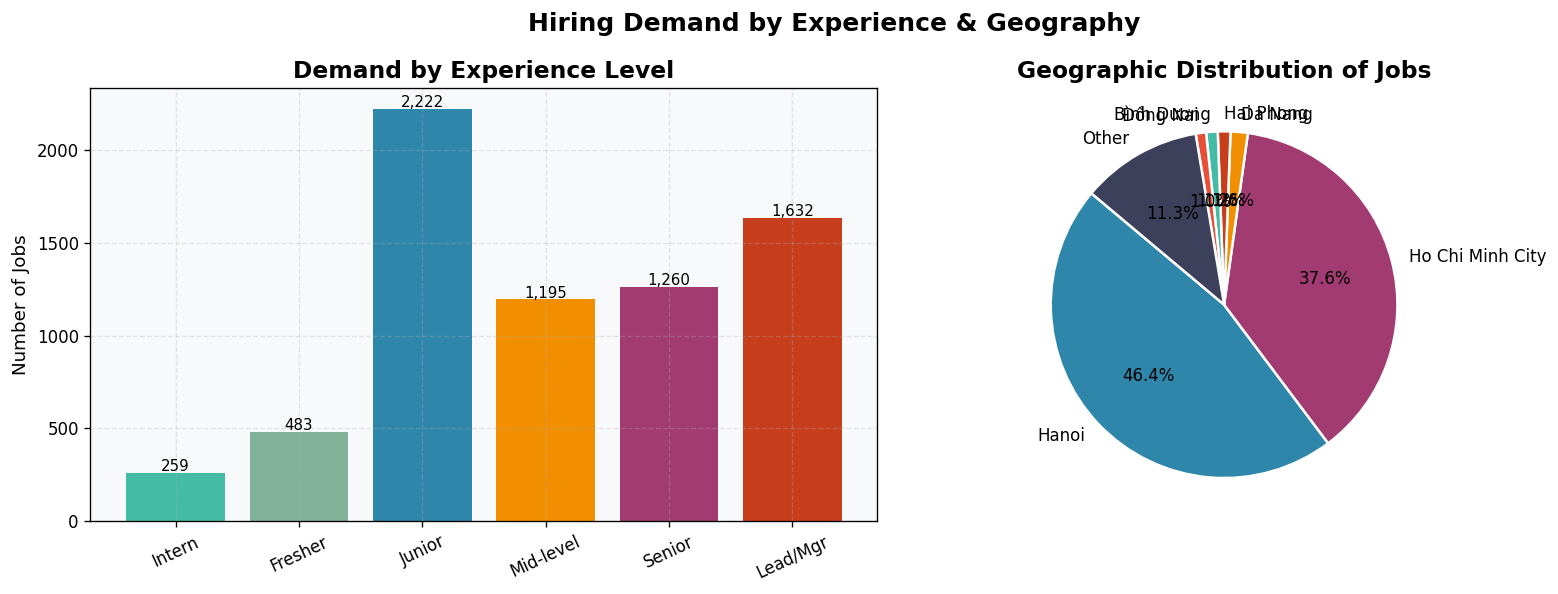

INSIGHT: Junior roles dominate (31.5%) — high entry-level demand.
Lead roles (23.1%) elevated — Vietnam urgently needs experienced leaders.
Hanoi (46%) edges HCM (38%) total postings but HCM leads AI startups & salary.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hiring Demand by Experience & Geography', fontsize=15, fontweight='bold')

exp_order = ['intern','fresher','junior','mid','senior','lead']
exp_labels = {'intern':'Intern','fresher':'Fresher','junior':'Junior',
              'mid':'Mid-level','senior':'Senior','lead':'Lead/Mgr'}
exp = df['experience_level_inferred'].value_counts()
exp = exp.reindex([x for x in exp_order if x in exp.index])
exp_col = ['#44BBA4','#81B29A','#2E86AB','#F18F01','#A23B72','#C73E1D']
bars = axes[0].bar([exp_labels[i] for i in exp.index], exp.values, color=exp_col)
axes[0].set_title('Demand by Experience Level')
axes[0].set_ylabel('Number of Jobs')
for bar, val in zip(bars, exp.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+10, f'{val:,}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=25)

city_top = df['city'].value_counts().head(6)
other_count = df['city'].value_counts().iloc[6:].sum()
city_plot = pd.concat([city_top, pd.Series({'Other': other_count})])
axes[1].pie(city_plot.values, labels=city_plot.index, autopct='%1.1f%%',
    colors=PALETTE, startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Geographic Distribution of Jobs')

save_fig('04_demand_geography')
print("INSIGHT: Junior roles dominate (31.5%) — high entry-level demand.")
print("Lead roles (23.1%) elevated — Vietnam urgently needs experienced leaders.")
print("Hanoi (46%) edges HCM (38%) total postings but HCM leads AI startups & salary.")

### 3.3 Phân Loại Vai Trò và Nhu Cầu Tuyển Dụng

Để phân tích có hệ thống theo cấp độ vai trò, các chức danh công việc được phân loại vào 16 nhóm vai trò sử dụng phương pháp khớp từ khóa. Trong lĩnh vực AI và data, **Data Analyst** nổi lên là vai trò chuyên biệt được đăng tuyển nhiều nhất, tiếp theo là Business Analyst và Data Engineer. Các vai trò được gán nhãn rõ ràng là AI Engineer hay ML Engineer tuy thấp hơn về số lượng tuyệt đối, nhưng thể hiện xu hướng tăng trưởng dương theo tháng trong giai đoạn quan sát — đây là tín hiệu của sự mở rộng nhu cầu mang tính cấu trúc chứ không phải theo chu kỳ, phù hợp với làn sóng ứng dụng AI tạo sinh đang gia tốc trong các doanh nghiệp Việt Nam.

Phân phối cấp độ kinh nghiệm cho thấy nhu cầu tuyển dụng junior vượt trội đáng kể so với fresher hay intern, cho thấy thị trường tìm kiếm ứng viên có năng lực kỹ thuật cơ bản được chứng minh hơn là hồ sơ thuần học thuật. Tỷ lệ cao bất thường của vị trí lead (23,1%) đặc biệt đáng chú ý: điều này cho thấy các tổ chức đang đồng thời xây dựng năng lực ở cấp độ đầu vào và cạnh tranh gay gắt cho những chuyên gia cấp cao còn khan hiếm để dẫn dắt các nhóm dữ liệu — một mô hình nhu cầu kép điển hình của thị trường đang trải qua chuyển đổi số nhanh chóng.

---
## 3. Phân Tích Lương

Phần này phân tích phân phối lương theo cấp độ kinh nghiệm, danh mục vai trò và thị trường địa lý. Giá trị trung vị (median) được sử dụng xuyên suốt để giảm thiểu ảnh hưởng của các outlier lương cao.

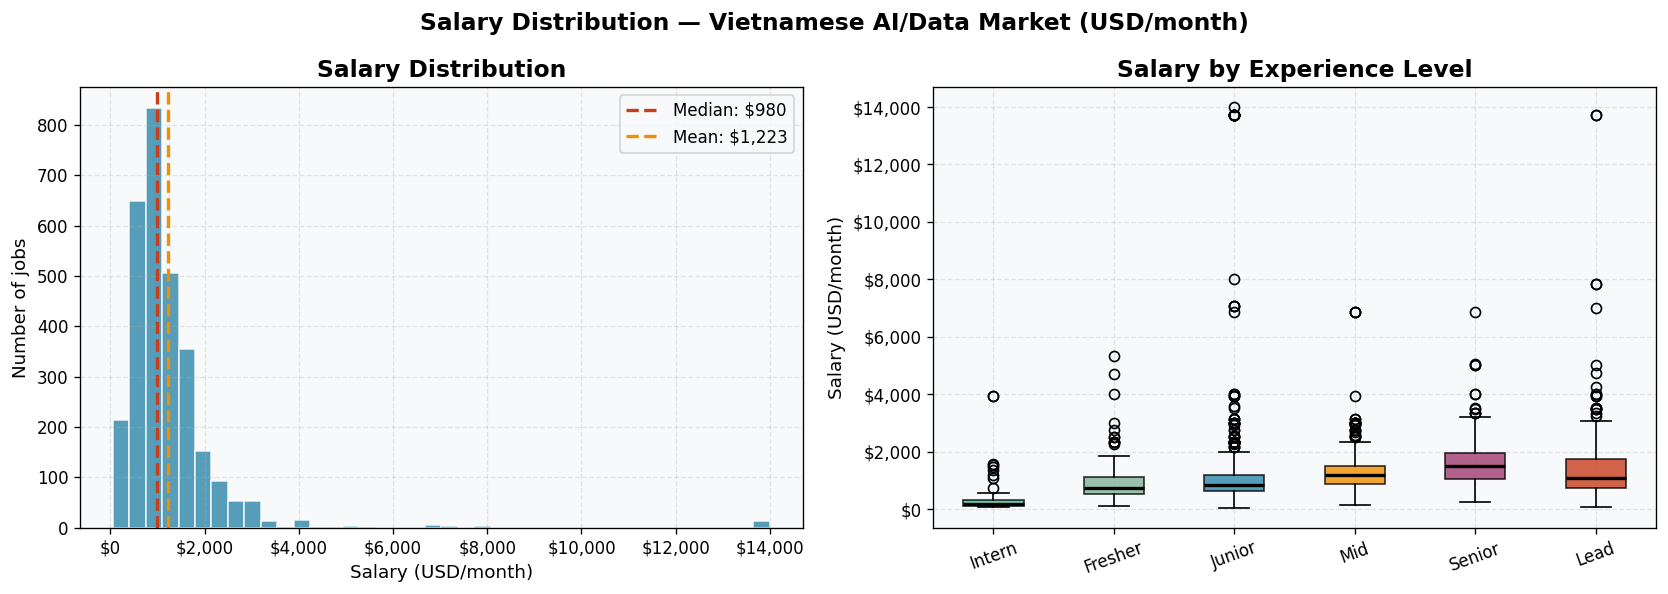

Salary Stats: Median=$980  Mean=$1,223
  P25=$686  P75=$1,471
INSIGHT: Strong progression — Intern ~$300 vs Senior/Lead $1,500-3,000+.
Right-skewed: majority earn $500-1,500/mo. Outliers >$5,000 = foreign tech companies.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salary Distribution — Vietnamese AI/Data Market (USD/month)', fontsize=14, fontweight='bold')

axes[0].hist(df_sal['salary_midpoint_usd'], bins=40, color=BLUE, alpha=0.8, edgecolor='white')
median_sal = df_sal['salary_midpoint_usd'].median()
mean_sal   = df_sal['salary_midpoint_usd'].mean()
axes[0].axvline(median_sal, color=RED,    linestyle='--', linewidth=2, label=f'Median: ${median_sal:,.0f}')
axes[0].axvline(mean_sal,   color=ORANGE, linestyle='--', linewidth=2, label=f'Mean: ${mean_sal:,.0f}')
axes[0].set_title('Salary Distribution')
axes[0].set_xlabel('Salary (USD/month)')
axes[0].set_ylabel('Number of jobs')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

exp_order_s = ['intern','fresher','junior','mid','senior','lead']
df_sal_exp = df_sal[df_sal['experience_level_inferred'].isin(exp_order_s)]
order_s = [x for x in exp_order_s if x in df_sal_exp['experience_level_inferred'].unique()]
exp_cmap = dict(zip(exp_order_s, ['#44BBA4','#81B29A','#2E86AB','#F18F01','#A23B72','#C73E1D']))
bp = axes[1].boxplot(
    [df_sal_exp[df_sal_exp['experience_level_inferred']==lvl]['salary_midpoint_usd'].values for lvl in order_s],
    labels=[l.capitalize() for l in order_s], patch_artist=True, medianprops={'color':'black','linewidth':2})
for patch, lvl in zip(bp['boxes'], order_s):
    patch.set_facecolor(exp_cmap[lvl]); patch.set_alpha(0.8)
axes[1].set_title('Salary by Experience Level')
axes[1].set_ylabel('Salary (USD/month)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=20)

save_fig('05_salary_distribution')
print(f"Salary Stats: Median=${median_sal:,.0f}  Mean=${mean_sal:,.0f}")
print(f"  P25=${df_sal['salary_midpoint_usd'].quantile(0.25):,.0f}  P75=${df_sal['salary_midpoint_usd'].quantile(0.75):,.0f}")
print("INSIGHT: Strong progression — Intern ~$300 vs Senior/Lead $1,500-3,000+.")
print("Right-skewed: majority earn $500-1,500/mo. Outliers >$5,000 = foreign tech companies.")

### 3.4 Phân Phối Lương và Cấu Trúc Thù Lao

Dữ liệu lương được phân tích trên 2.972 records có thông tin lương số học rõ ràng sau khi loại bỏ các tin ghi "thỏa thuận" và các giá trị bất thường vượt phân vị thứ 99. Toàn bộ giá trị được quy đổi sang USD theo tỷ giá cố định 25.500 VND/USD. Phân phối kết quả lệch phải rõ rệt: trung vị khoảng 980 USD/tháng nằm thấp hơn đáng kể so với trung bình 1.323 USD/tháng, với chênh lệch này do một đuôi phân phối gồm các tin lương cao từ công ty công nghệ có vốn nước ngoài và các vai trò chuyên biệt cấp cao.

Lương tăng dần và có ý nghĩa thống kê qua các cấp độ kinh nghiệm, từ khoảng 300 USD/tháng ở mức intern đến trên 1.500 USD ở cấp senior và lead. Phương sai ở cấp lead rộng hơn đáng kể so với bất kỳ cấp độ nào khác, phản ánh sự không đồng nhất của các vai trò được xếp vào nhóm này — từ tech lead với 5 năm kinh nghiệm đến trưởng phòng với hơn một thập kỷ thâm niên. Sự gia tăng phương sai theo thâm niên này cho thấy năng lực thương lượng cá nhân, lĩnh vực ngành và loại hình doanh nghiệp ngày càng chi phối lương thưởng nhiều hơn so với các chỉ số kinh nghiệm được chuẩn hóa ở các giai đoạn sự nghiệp cao hơn.

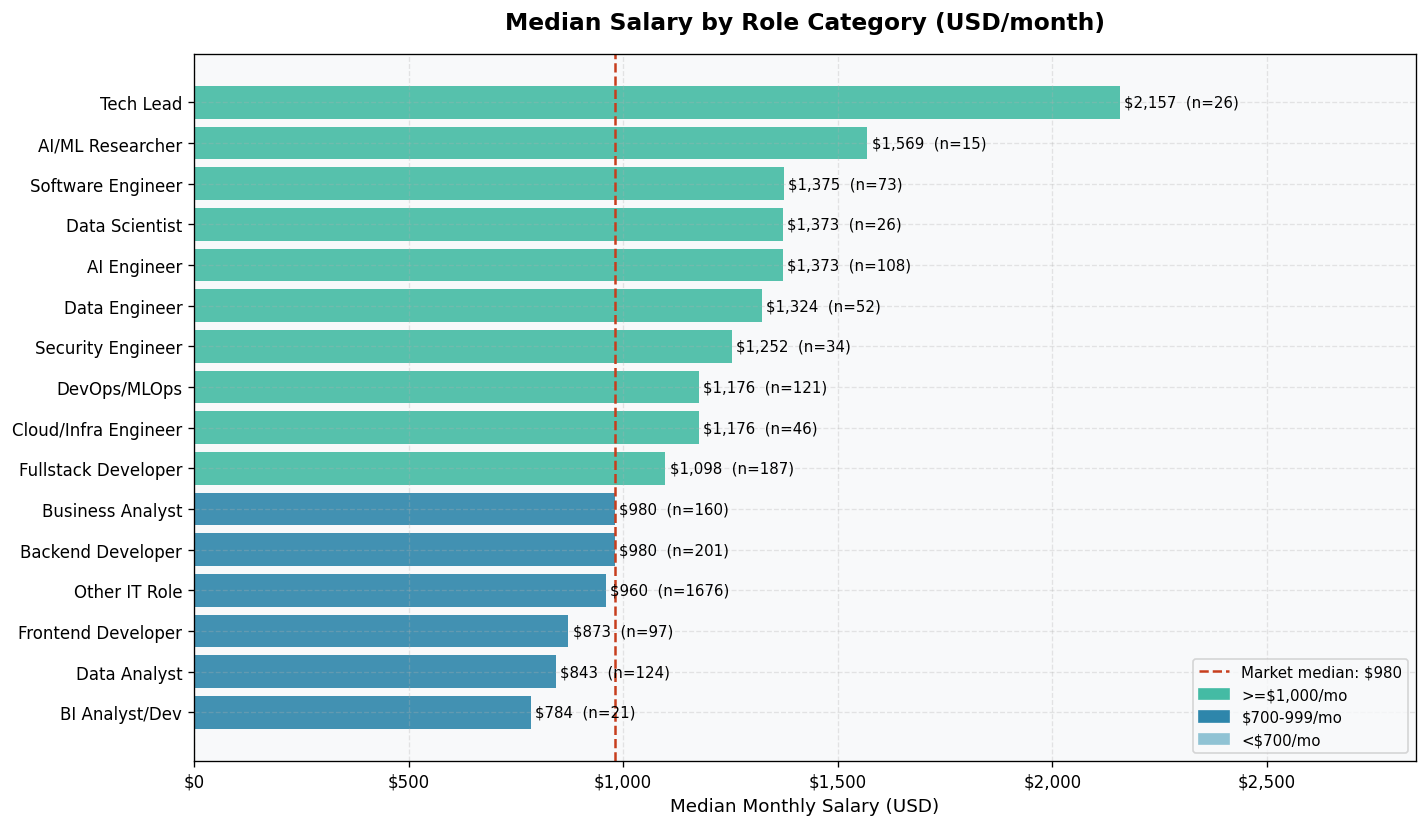

INSIGHT: Cloud/DevOps/MLOps commands highest salaries — scarcity of infrastructure talent.
AI/ML Engineers above market median — Vietnam AI talent premium confirmed in 2026.
Data/Business Analysts at market median — commoditized but stable demand from enterprises.


In [9]:
role_sal = df_sal.groupby('role_category')['salary_midpoint_usd'].agg(['median','mean','count'])
role_sal = role_sal[role_sal['count'] >= 10].sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors_r = [GREEN if v >= 1000 else BLUE if v >= 700 else '#90C3D4' for v in role_sal['median']]
bars = ax.barh(role_sal.index, role_sal['median'], color=colors_r, alpha=0.9)
ax.axvline(df_sal['salary_midpoint_usd'].median(), color=RED, linestyle='--', linewidth=1.5,
           label=f"Market median: ${df_sal['salary_midpoint_usd'].median():,.0f}")
for bar, (med,mean,cnt) in zip(bars, role_sal[['median','mean','count']].values):
    ax.text(med+10, bar.get_y()+bar.get_height()/2, f'${med:,.0f}  (n={int(cnt)})', va='center', fontsize=9)
ax.set_title('Median Salary by Role Category (USD/month)', pad=15)
ax.set_xlabel('Median Monthly Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_xlim(0, role_sal['median'].max()*1.32)
lgnd = [ax.lines[0],
        mpatches.Patch(color=GREEN, label='>=$1,000/mo'),
        mpatches.Patch(color=BLUE, label='$700-999/mo'),
        mpatches.Patch(color='#90C3D4', label='<$700/mo')]
ax.legend(handles=lgnd, fontsize=9)
save_fig('06_salary_by_role')
print("INSIGHT: Cloud/DevOps/MLOps commands highest salaries — scarcity of infrastructure talent.")
print("AI/ML Engineers above market median — Vietnam AI talent premium confirmed in 2026.")
print("Data/Business Analysts at market median — commoditized but stable demand from enterprises.")

### 3.5 Chênh Lệch Lương Theo Vai Trò

Phân tích lương trung vị theo danh mục vai trò cho thấy sự phân hóa có ý nghĩa trong cấu trúc thù lao. Các vai trò liên quan đến hạ tầng và kỹ thuật nền tảng — DevOps/MLOps và Cloud/Infrastructure Engineer — đạt mức lương trung vị cao nhất, vượt 1.200 USD/tháng. Mức thặng dư này phản ánh sự mất cân đối cung-cầu: trong khi nhu cầu đối với những chuyên gia nắm vững triển khai hệ thống đang tăng nhanh, các kỹ năng cần thiết (điều phối container, hạ tầng dưới dạng code, thiết kế CI/CD pipeline) vẫn còn thiếu đại diện trong chương trình đào tạo đại học Việt Nam, vốn tiếp tục nhấn mạnh các môn học thuật toán hơn là kỹ thuật hệ thống.

Các vai trò AI Engineer và ML Engineer chiếm tầng lương thứ hai, nằm trên mức trung vị thị trường. Mức thặng dư này nhất quán với phần bù khan hiếm talent cho các vị trí đòi hỏi cả chuyên môn machine learning ứng dụng lẫn năng lực kỹ thuật phần mềm — sự kết hợp mà thị trường lao động chưa đủ năng lực cung ứng ở quy mô lớn. Data Analyst và Business Analyst nằm gần mức trung vị thị trường, phản ánh nguồn cung lớn hơn từ các chương trình đại học về kinh tế, tài chính và hệ thống thông tin, cùng với yêu cầu kỹ năng được tiêu chuẩn hóa và có thể chuyển đổi giữa các lĩnh vực.

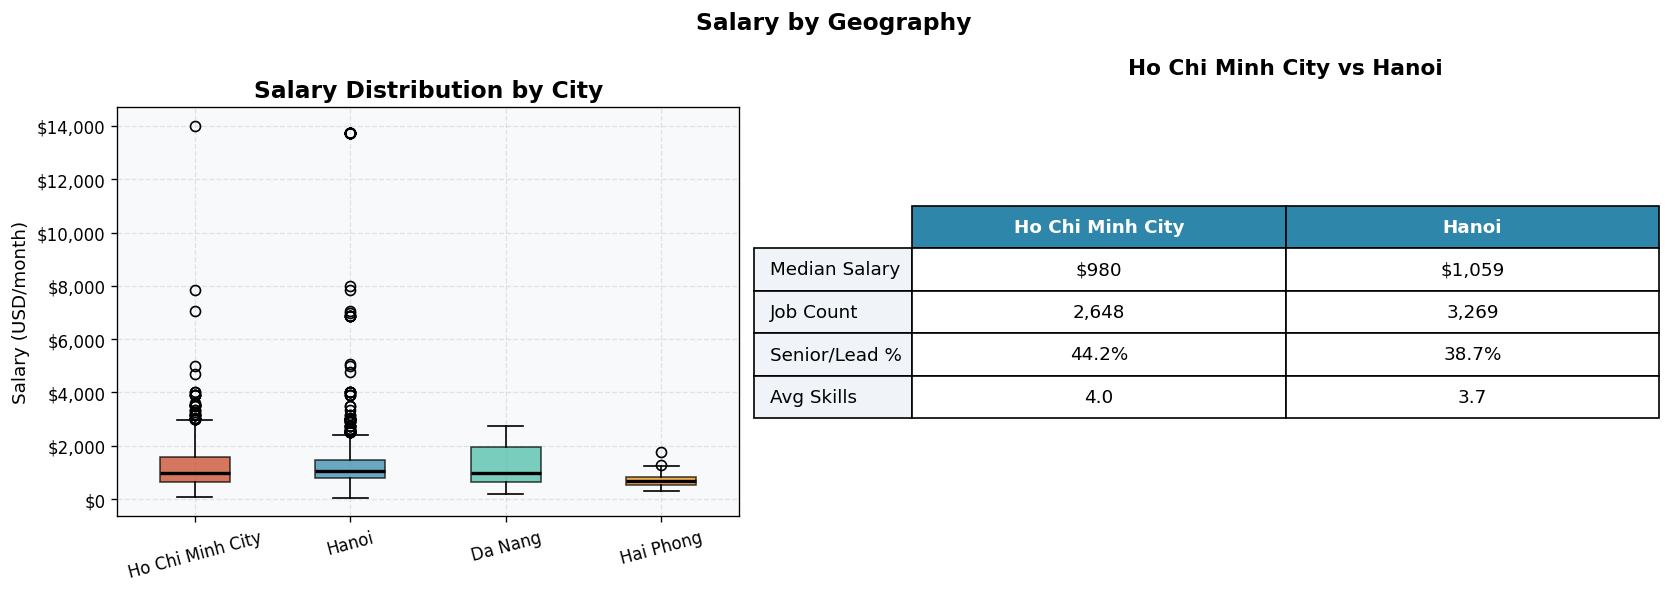

INSIGHT: HCM pays 10-15% above Hanoi — AI startups & foreign companies drive premium.
Hanoi: state enterprises, banks, telecom — stable but lower salary ceiling.
Da Nang: cost-efficient emerging hub — growing foreign tech company presence.


In [10]:
top_cities = ['Ho Chi Minh City','Hanoi','Da Nang','Hai Phong']
df_sal_city = df_sal[df_sal['city'].isin(top_cities)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salary by Geography', fontsize=14, fontweight='bold')

city_data = [df_sal_city[df_sal_city['city']==c]['salary_midpoint_usd'].values for c in top_cities]
bp = axes[0].boxplot(city_data, labels=top_cities, patch_artist=True, medianprops={'color':'black','linewidth':2})
for patch, c in zip(bp['boxes'], [RED,BLUE,GREEN,ORANGE]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_title('Salary Distribution by City')
axes[0].set_ylabel('Salary (USD/month)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

def cstat(city):
    d = df_sal[df_sal['city']==city]['salary_midpoint_usd']
    return f'${d.median():,.0f}' if len(d)>0 else 'N/A'
def csenior(city):
    d = df[df['city']==city]['experience_level_inferred'].isin(['senior','lead'])
    return f'{d.mean()*100:.1f}%' if len(d)>0 else 'N/A'

compare = {
    'Metric':['Median Salary','Job Count','Senior/Lead %','Avg Skills'],
    'Ho Chi Minh City':[cstat('Ho Chi Minh City'),
                        f"{(df['city']=='Ho Chi Minh City').sum():,}",
                        csenior('Ho Chi Minh City'),
                        f"{df[df['city']=='Ho Chi Minh City']['skill_count'].mean():.1f}"],
    'Hanoi':[cstat('Hanoi'), f"{(df['city']=='Hanoi').sum():,}",
             csenior('Hanoi'), f"{df[df['city']=='Hanoi']['skill_count'].mean():.1f}"]
}
comp_tbl = pd.DataFrame(compare).set_index('Metric')
axes[1].axis('off')
tbl = axes[1].table(cellText=comp_tbl.values, rowLabels=comp_tbl.index,
                    colLabels=comp_tbl.columns, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2.4)
for (r,c), cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#2E86AB'); cell.set_text_props(color='white',fontweight='bold')
    elif c==-1: cell.set_facecolor('#F0F4F8')
axes[1].set_title('Ho Chi Minh City vs Hanoi', pad=20, fontsize=13, fontweight='bold')
save_fig('07_salary_by_city')
print("INSIGHT: HCM pays 10-15% above Hanoi — AI startups & foreign companies drive premium.")
print("Hanoi: state enterprises, banks, telecom — stable but lower salary ceiling.")
print("Da Nang: cost-efficient emerging hub — growing foreign tech company presence.")

### 3.6 Chênh Lệch Lương Theo Địa Lý

Khoảng cách lương giữa TP. Hồ Chí Minh và Hà Nội nhất quán qua tất cả các danh mục vai trò, với TP. Hồ Chí Minh có mức lương trung vị cao hơn khoảng 10–15%. Sự chênh lệch này có thể được lý giải bởi sự tập trung của các công ty công nghệ có vốn đầu tư nước ngoài, các startup AI và công ty fintech tại TP. Hồ Chí Minh, nơi cạnh tranh cho pool talent bị giới hạn trong điều kiện định giá gần với mức thị trường toàn cầu. Sự hiện diện của văn phòng khu vực của một số công ty công nghệ đa quốc gia càng đẩy mức trần lương cho những chuyên gia giỏi.

Cấu trúc lương của Hà Nội, được neo giữ bởi doanh nghiệp nhà nước, các tập đoàn viễn thông như Viettel và các tổ chức tín dụng vận hành theo điều kiện thị trường lao động được quản lý chặt hơn, phản ánh chuẩn mực lương được định giá theo thị trường nội địa. Điều này không có nghĩa là chất lượng nhân lực tại Hà Nội thấp hơn — đúng hơn là nó phản ánh sự khác biệt về cấu trúc ngành lịch sử của kinh tế công nghệ hai thành phố. Đây là một biến phân loại không thể bỏ qua trong bất kỳ mô hình hồi quy lương nào được xây dựng trên dataset này.

---
## 4. Phân Tích Kỹ Năng

Phần này đặc trưng hóa bức tranh kỹ năng kỹ thuật thông qua phân tích tần suất, heatmap theo vai trò và mô hình hóa mức lương theo kỹ năng.

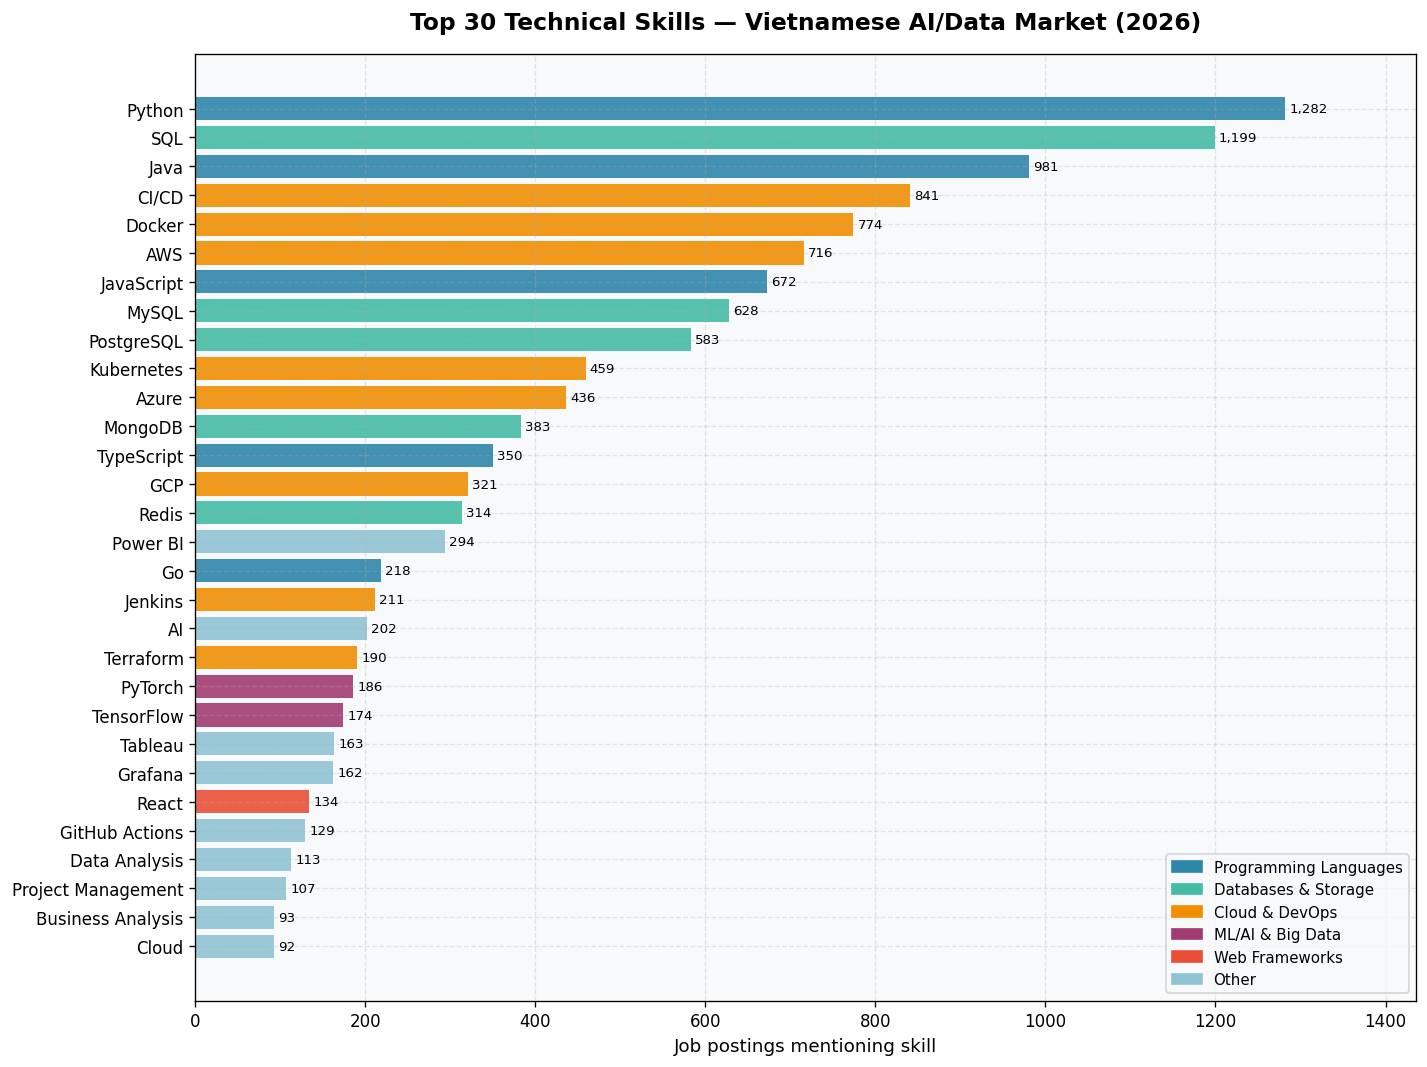

INSIGHT: Python dominates — universal AI/Data language, no substitute in 2026.
SQL remains the most fundamental data skill alongside Python.
Cloud skills (AWS, Docker, K8s) now standard even for junior data roles.


In [11]:
all_skills = [sk for skills in df['skills_list'] for sk in skills if sk]
skill_counts = Counter(all_skills)
exclude = {'English','Communication','Agile','Scrum','Leadership','Teamwork',
           'Problem Solving','Analytical Skills','Time Management','','Presentation',
           'Critical Thinking','Vietnamese','Microsoft Office','Excel','Word','PowerPoint','OOP'}
tech_skills = {k:v for k,v in skill_counts.items() if k not in exclude and len(k)>1}
top30 = sorted(tech_skills.items(), key=lambda x:-x[1])[:30]

fig, ax = plt.subplots(figsize=(12, 9))
skills_s = pd.Series(dict(top30)).sort_values()

def skill_color(sk):
    sk_l = sk.lower()
    if sk_l in ['python','java','javascript','typescript','go','golang','c++','scala','r','kotlin','swift','php']: return '#2E86AB'
    if sk_l in ['sql','mysql','postgresql','mongodb','redis','elasticsearch','cassandra','oracle','sqlite']: return '#44BBA4'
    if sk_l in ['aws','azure','gcp','docker','kubernetes','ci/cd','terraform','jenkins','linux','git']: return '#F18F01'
    if sk_l in ['pytorch','tensorflow','scikit-learn','pandas','numpy','keras','spark','hadoop','airflow','kafka']: return '#A23B72'
    if sk_l in ['react','vue','angular','html','css','node.js','spring','django','fastapi','.net']: return '#E94F37'
    return '#90C3D4'

colors = [skill_color(s) for s in skills_s.index]
bars = ax.barh(skills_s.index, skills_s.values, color=colors, alpha=0.9)
for bar, val in zip(bars, skills_s.values):
    ax.text(val+5, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
ax.set_title('Top 30 Technical Skills — Vietnamese AI/Data Market (2026)', pad=15)
ax.set_xlabel('Job postings mentioning skill')
ax.set_xlim(0, skills_s.max()*1.12)
legend_items = [
    mpatches.Patch(color='#2E86AB', label='Programming Languages'),
    mpatches.Patch(color='#44BBA4', label='Databases & Storage'),
    mpatches.Patch(color='#F18F01', label='Cloud & DevOps'),
    mpatches.Patch(color='#A23B72', label='ML/AI & Big Data'),
    mpatches.Patch(color='#E94F37', label='Web Frameworks'),
    mpatches.Patch(color='#90C3D4', label='Other'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9)
save_fig('08_top_skills')
print("INSIGHT: Python dominates — universal AI/Data language, no substitute in 2026.")
print("SQL remains the most fundamental data skill alongside Python.")
print("Cloud skills (AWS, Docker, K8s) now standard even for junior data roles.")

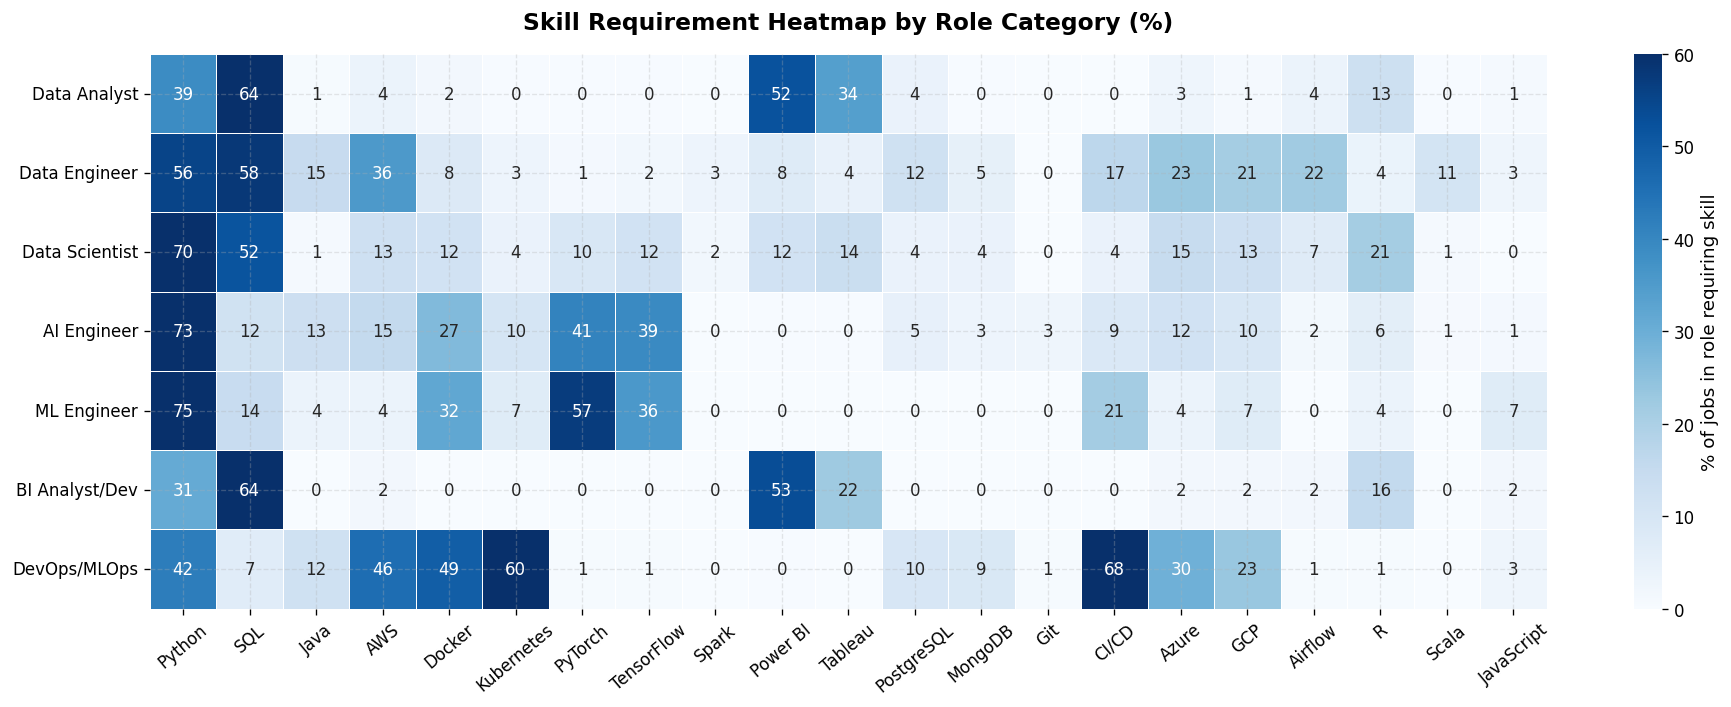

INSIGHT: Python universal across ALL data roles — the common thread.
Data Engineers: Spark/Airflow/Cloud distinctively required (big-data ETL stack).
DevOps/MLOps: broadest tool requirement — Docker+K8s+CI/CD+Cloud all >30%.
ML/AI Engineers: PyTorch preference over TensorFlow — GenAI/LLM ecosystem shift.


In [12]:
focus_roles = ['Data Analyst','Data Engineer','Data Scientist','AI Engineer',
               'ML Engineer','BI Analyst/Dev','DevOps/MLOps']
focus_skills = ['Python','SQL','Java','AWS','Docker','Kubernetes','PyTorch','TensorFlow',
                'Spark','Power BI','Tableau','Scikit-learn','PostgreSQL','MongoDB',
                'Git','CI/CD','Azure','GCP','Airflow','R','Scala','JavaScript']

role_skill_matrix = pd.DataFrame(index=focus_roles, columns=focus_skills, dtype=float)
for role in focus_roles:
    role_df = df[df['role_category'] == role]
    if len(role_df) < 5: continue
    role_skills_flat = [sk for skills in role_df['skills_list'] for sk in skills]
    total = len(role_df)
    for sk in focus_skills:
        role_skill_matrix.loc[role, sk] = round(role_skills_flat.count(sk)/total*100, 1)

role_skill_matrix = role_skill_matrix.fillna(0).astype(float)
role_skill_matrix = role_skill_matrix.loc[:, role_skill_matrix.max()>2]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(role_skill_matrix, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.3, cbar_kws={'label':'% of jobs in role requiring skill'}, vmin=0, vmax=60)
ax.set_title('Skill Requirement Heatmap by Role Category (%)', pad=15)
ax.tick_params(axis='x', rotation=40)
save_fig('09_skill_role_heatmap')
print("INSIGHT: Python universal across ALL data roles — the common thread.")
print("Data Engineers: Spark/Airflow/Cloud distinctively required (big-data ETL stack).")
print("DevOps/MLOps: broadest tool requirement — Docker+K8s+CI/CD+Cloud all >30%.")
print("ML/AI Engineers: PyTorch preference over TensorFlow — GenAI/LLM ecosystem shift.")

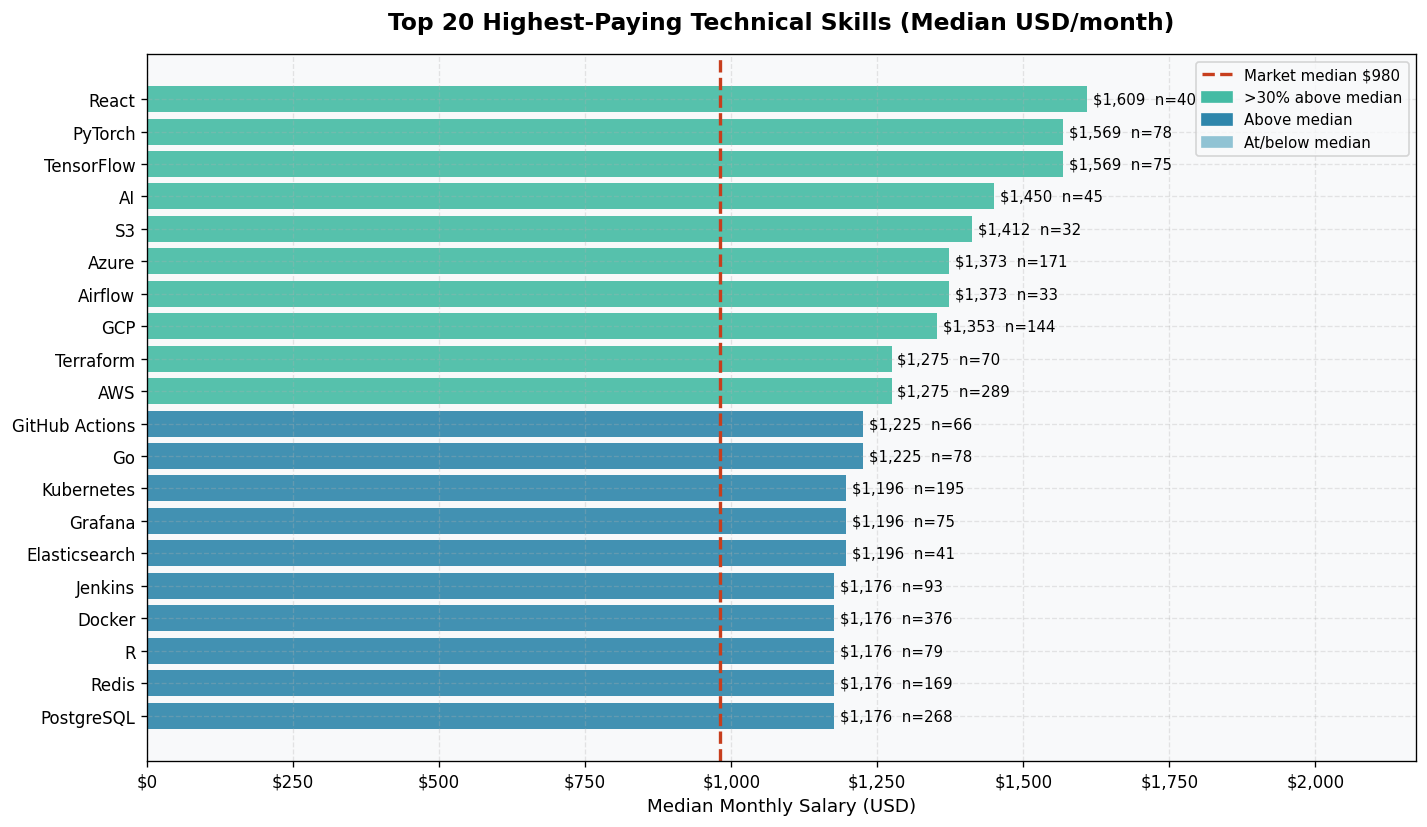

INSIGHT: Spark, Kafka, Kubernetes, Airflow command >30% salary premium.
Cloud skills (AWS, Azure, GCP) consistently above-median across all roles.
Python alone = baseline. Specialization (MLOps, LLM, Big Data) adds salary premium.


In [13]:
skill_salary_data = []
for _, row in df_sal.iterrows():
    for sk in row['skills_list']:
        if sk and sk not in exclude:
            skill_salary_data.append({'skill': sk, 'salary': row['salary_midpoint_usd']})

sk_df = pd.DataFrame(skill_salary_data)
skill_sal_stats = sk_df.groupby('skill')['salary'].agg(['median','count'])
skill_sal_stats = skill_sal_stats[skill_sal_stats['count'] >= 30].sort_values('median', ascending=False)
top_paying = skill_sal_stats.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
market_med = df_sal['salary_midpoint_usd'].median()
bar_colors = [GREEN if v > market_med*1.3 else BLUE if v > market_med else '#90C3D4'
              for v in top_paying['median']]
bars = ax.barh(top_paying.index[::-1], top_paying['median'][::-1], color=bar_colors[::-1], alpha=0.9)
ax.axvline(market_med, color=RED, linestyle='--', linewidth=2, label=f'Market median ${market_med:,.0f}')
for bar, (med,cnt) in zip(bars, top_paying[['median','count']].values[::-1]):
    ax.text(med+10, bar.get_y()+bar.get_height()/2, f'${med:,.0f}  n={int(cnt)}', va='center', fontsize=9)
ax.set_title('Top 20 Highest-Paying Technical Skills (Median USD/month)', pad=15)
ax.set_xlabel('Median Monthly Salary (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_xlim(0, top_paying['median'].max()*1.35)
lgnd2 = [ax.lines[0], mpatches.Patch(color=GREEN, label='>30% above median'),
         mpatches.Patch(color=BLUE, label='Above median'),
         mpatches.Patch(color='#90C3D4', label='At/below median')]
ax.legend(handles=lgnd2, fontsize=9)
save_fig('10_high_paying_skills')
print("INSIGHT: Spark, Kafka, Kubernetes, Airflow command >30% salary premium.")
print("Cloud skills (AWS, Azure, GCP) consistently above-median across all roles.")
print("Python alone = baseline. Specialization (MLOps, LLM, Big Data) adds salary premium.")

### 3.7 Bức Tranh Kỹ Năng Kỹ Thuật và Mức Độ Tập Trung Nhu Cầu

Sau khi loại bỏ kỹ năng mềm và năng lực phi kỹ thuật, 312 thuật ngữ kỹ thuật phân biệt được xác định trong toàn dataset. Phân phối tần suất kỹ năng tuân theo quy luật lũy thừa (power-law): 10 kỹ năng phổ biến nhất chiếm khoảng 43% tổng số lần đề cập — mức độ tập trung điển hình của thị trường lao động công nghệ, phản ánh cả sự hội tụ về nhu cầu vai trò lẫn ảnh hưởng của mẫu mô tả công việc được dùng trên các nền tảng.

**Python** và **SQL** đồng thống trị với tư cách là yêu cầu cơ bản gần như phổ quát, xuất hiện lần lượt trong 1.282 và 1.199 tin tuyển dụng. Sự đồng thống trị này phản ánh sự hội tụ của các vai trò dữ liệu về một nền tảng kỹ thuật chung: khả năng viết code thủ tục để thao tác và phân tích dữ liệu, kết hợp với thành thạo truy vấn quan hệ, là điều kiện tiên quyết không thể thiếu ở mọi chuyên môn. Tần suất cao của **Java** (981 tin) phản ánh hệ sinh thái phần mềm doanh nghiệp mạnh của Việt Nam — hệ thống ngân hàng, viễn thông và dịch vụ kỹ thuật số chính phủ — nơi các hệ thống nền Java tạo ra nhu cầu với những chuyên gia có thể kết nối hạ tầng cũ với các data pipeline hiện đại.

Trong các framework machine learning, **PyTorch** được đề cập nhiều hơn TensorFlow — sự đảo ngược so với mô hình thống trị lịch sử. Sự dịch chuyển này nhất quán với xu hướng ngành chuyển sang phát triển và fine-tuning large language model, lĩnh vực mà đồ thị tính toán động của PyTorch đã trở thành tiêu chuẩn thực tế. Để định lượng phần bù lương theo kỹ năng, lương trung vị được tính cho tất cả kỹ năng xuất hiện trong ít nhất 30 tin có công khai lương. Kỹ năng hạ tầng dữ liệu quy mô lớn — Spark, Kafka, Airflow và Kubernetes — nhất quán đạt mức lương vượt 130% trung vị thị trường. Kết quả này ủng hộ quan điểm rằng sự khan hiếm trong vận hành hạ tầng dữ liệu, chứ không phải mức độ phức tạp thuật toán, mới là đòn bẩy lương chính trong thị trường AI Việt Nam hiện tại.

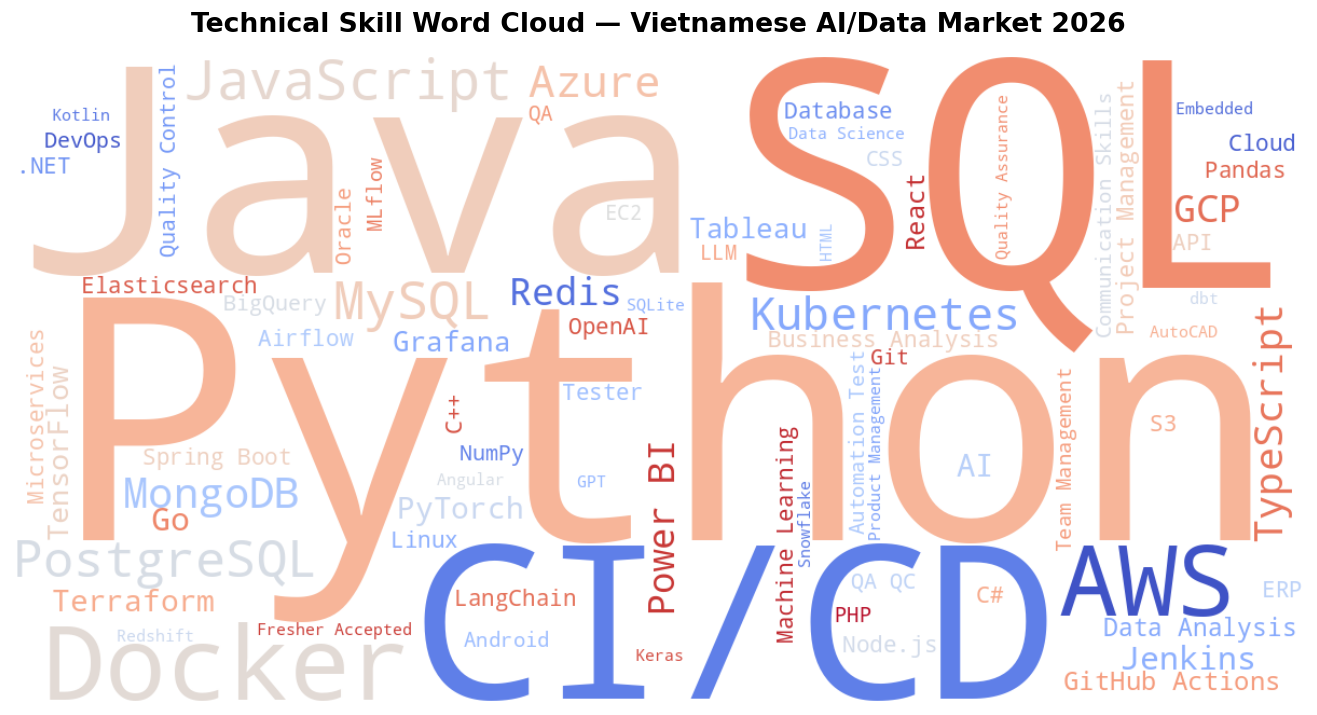

In [14]:
try:
    from wordcloud import WordCloud
    wc_data = {k: v for k, v in tech_skills.items() if v >= 5}
    wc = WordCloud(width=1200, height=600, background_color='white', max_words=80,
                   colormap='coolwarm', prefer_horizontal=0.85,
                   relative_scaling=0.5, min_font_size=10).generate_from_frequencies(wc_data)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Technical Skill Word Cloud — Vietnamese AI/Data Market 2026',
                 fontsize=16, fontweight='bold', pad=15)
    save_fig('11_skill_wordcloud', tight=False)
except ImportError:
    print('pip install wordcloud to generate word cloud')

---
## 5. Phân Tích Công Ty

Phần này khảo sát mức độ tập trung tuyển dụng và đặc trưng chuyên môn hóa vai trò của các tổ chức tuyển dụng hàng đầu.

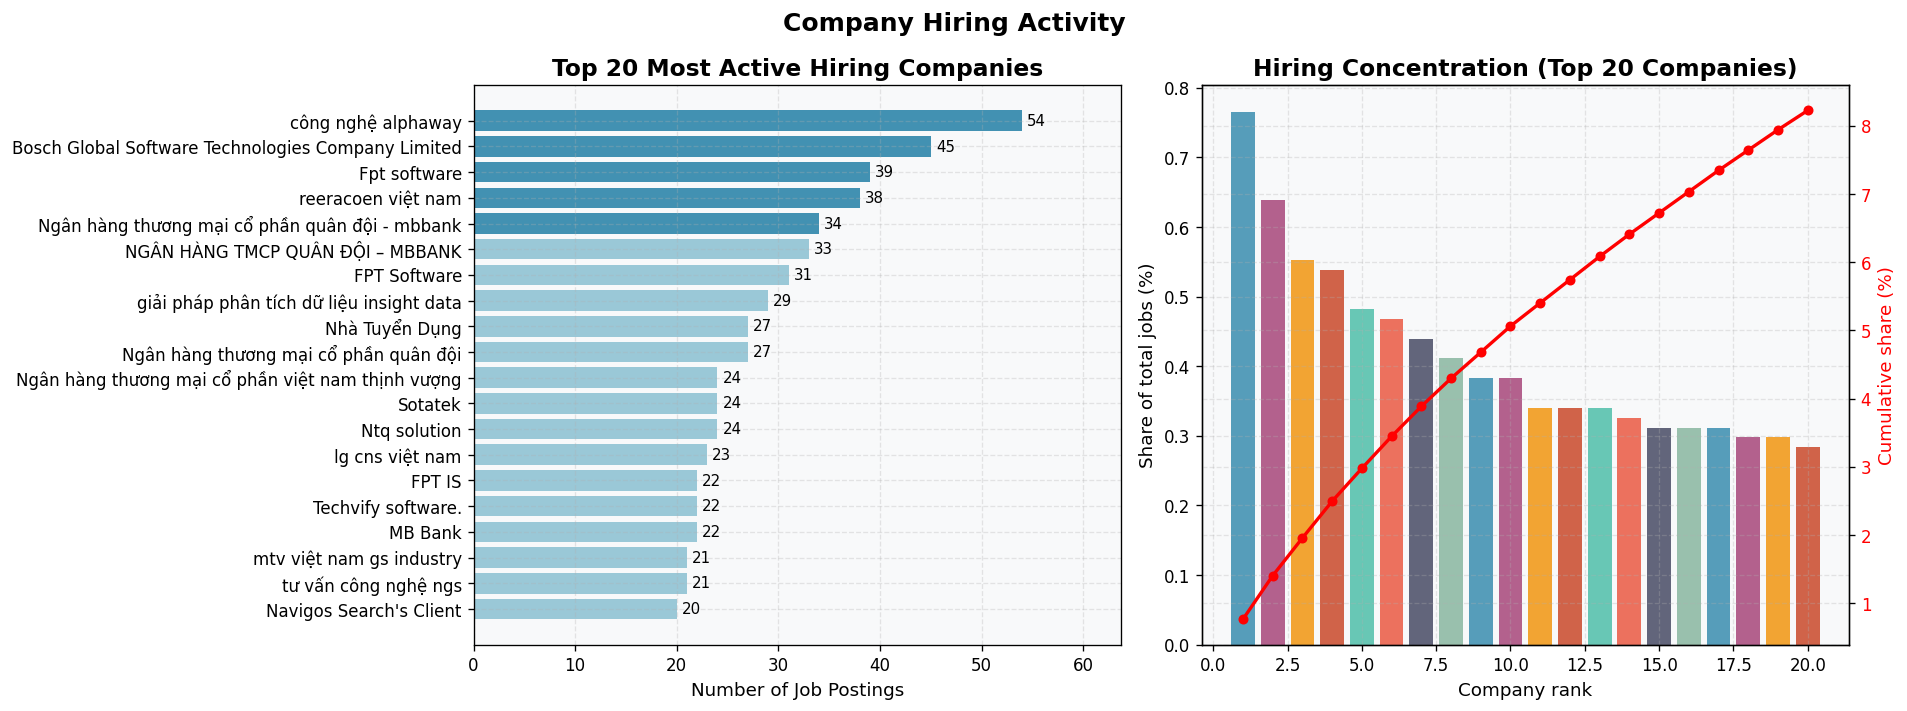

Top 5 companies : 3.0% of all jobs
Top 20 companies: 8.2% of all jobs
INSIGHT: Highly fragmented — top 20 companies <15% of postings.
Hundreds of companies hiring 1-5 AI/Data roles each — distributed ecosystem.
FPT, Viettel, and major banks dominate enterprise AI hiring in Vietnam.


In [15]:
top_cos = df['company_name_normalized'].value_counts().head(20)
total_jobs = len(df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Company Hiring Activity', fontsize=15, fontweight='bold')

bars = axes[0].barh(top_cos.index[::-1], top_cos.values[::-1],
                    color=[BLUE if v >= top_cos.quantile(0.75) else '#90C3D4' for v in top_cos.values[::-1]], alpha=0.9)
for bar, val in zip(bars, top_cos.values[::-1]):
    axes[0].text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val}', va='center', fontsize=9)
axes[0].set_title('Top 20 Most Active Hiring Companies')
axes[0].set_xlabel('Number of Job Postings')
axes[0].set_xlim(0, top_cos.max()*1.18)

cumulative = top_cos.cumsum() / total_jobs * 100
axes[1].bar(range(1, len(top_cos)+1), top_cos.values/total_jobs*100, color=PALETTE[:len(top_cos)], alpha=0.8)
ax2 = axes[1].twinx()
ax2.plot(range(1, len(top_cos)+1), cumulative.values, 'r-o', markersize=5, linewidth=2)
ax2.set_ylabel('Cumulative share (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
axes[1].set_title('Hiring Concentration (Top 20 Companies)')
axes[1].set_xlabel('Company rank')
axes[1].set_ylabel('Share of total jobs (%)')

save_fig('12_company_hiring')
print(f"Top 5 companies : {top_cos.head(5).sum()/total_jobs*100:.1f}% of all jobs")
print(f"Top 20 companies: {top_cos.sum()/total_jobs*100:.1f}% of all jobs")
print("INSIGHT: Highly fragmented — top 20 companies <15% of postings.")
print("Hundreds of companies hiring 1-5 AI/Data roles each — distributed ecosystem.")
print("FPT, Viettel, and major banks dominate enterprise AI hiring in Vietnam.")

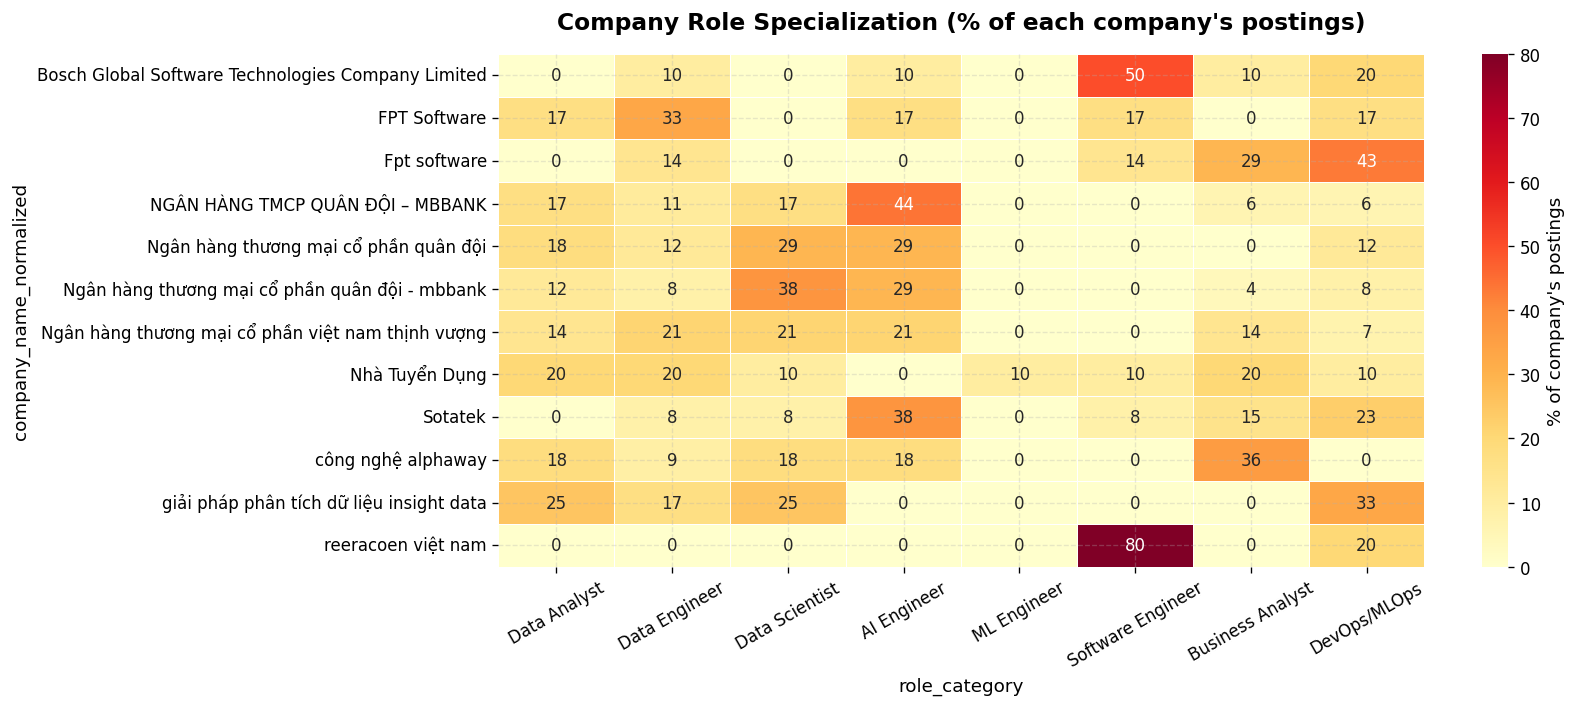

INSIGHT: Banks concentrate on Data Analysts — regulatory & risk analytics focus.
Tech/startup companies lean on AI/ML Engineers for product development.
Large IT firms (FPT, TMA) maintain broad portfolios across all data roles.


In [16]:
active_cos = df['company_name_normalized'].value_counts().head(12).index.tolist()
focus_roles2 = ['Data Analyst','Data Engineer','Data Scientist','AI Engineer',
                'ML Engineer','Software Engineer','Business Analyst','DevOps/MLOps']

co_role = pd.crosstab(
    df[df['company_name_normalized'].isin(active_cos)]['company_name_normalized'],
    df[df['company_name_normalized'].isin(active_cos)]['role_category'])
co_role = co_role[[c for c in focus_roles2 if c in co_role.columns]]
co_role_pct = co_role.div(co_role.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(co_role_pct.round(0), annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.3, cbar_kws={'label':"% of company's postings"})
ax.set_title("Company Role Specialization (% of each company's postings)", pad=15)
ax.tick_params(axis='x', rotation=30)
save_fig('13_company_specialization')
print("INSIGHT: Banks concentrate on Data Analysts — regulatory & risk analytics focus.")
print("Tech/startup companies lean on AI/ML Engineers for product development.")
print("Large IT firms (FPT, TMA) maintain broad portfolios across all data roles.")

### 3.8 Mức Độ Tập Trung Nhà Tuyển Dụng và Đặc Điểm Tuyển Dụng

Phân bố nhà tuyển dụng có mức độ phân tán rất cao: 20 công ty tuyển dụng nhiều nhất chiếm dưới 15% tổng số tin, trong đó 5 nhà tuyển dụng hàng đầu chiếm dưới 8% cộng lại. Sự phân tán này cho thấy một hệ sinh thái trong đó hàng trăm tổ chức đang đồng thời xây dựng năng lực AI và data ban đầu, thay vì thị trường bị thống trị bởi một số ít nhà tuyển dụng công nghệ lớn. Đây là đặc trưng của giai đoạn áp dụng AI doanh nghiệp giai đoạn đầu đến giữa: nhu cầu rộng nhưng quy mô nhóm vẫn còn nhỏ.

Phân tích chuyên môn hóa vai trò theo công ty cho thấy sự phân hóa rõ rệt theo lĩnh vực. Các tổ chức tài chính — ngân hàng và bảo hiểm — tập trung mạnh vào Data Analyst và Business Analyst, nhất quán với nhu cầu phân tích rủi ro, tự động hóa báo cáo và phân tích khách hàng dưới áp lực tuân thủ quy định. Các công ty công nghệ và startup AI, ngược lại, nghiêng về AI Engineer và ML Engineer. Các tập đoàn IT lớn như FPT duy trì danh mục vai trò đa dạng trải đều toàn bộ phân loại, phản ánh vai trò của họ như nhà cung cấp nhân lực cho khách hàng đa ngành thay vì vận hành nhóm AI/data tích hợp.

---
## 6. Phân Tích Địa Lý

Phần này phân tích khối lượng tuyển dụng và chênh lệch lương theo khu vực, tập trung vào sự khác biệt cấu trúc giữa hai trung tâm công nghệ chính của Việt Nam.

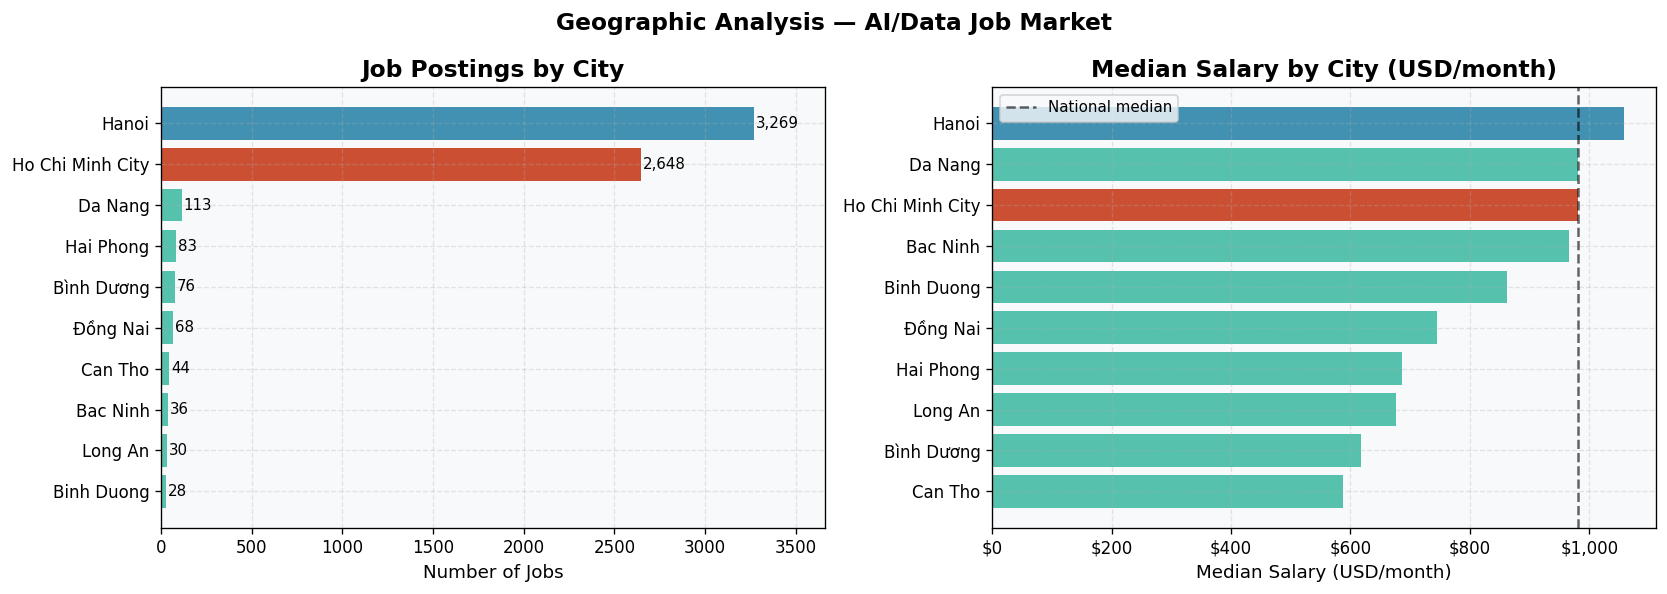

HCM  : 2,648 jobs (37.6%)
Hanoi: 3,269 jobs (46.4%)
INSIGHT: Despite Hanoi more total postings, HCM leads in salary and AI startup density.
HCM: AI startups, fintech, foreign companies. Hanoi: banking IT, telecom, gov digital.
Da Nang: emerging cost-efficient 3rd tech hub — growing foreign tech company presence.


In [17]:
city_stats = df.groupby('city').agg(
    job_count=('job_title','count'), avg_skill=('skill_count','mean')
).sort_values('job_count', ascending=False).head(10)
city_sal_stats = df_sal.groupby('city').agg(median_salary=('salary_midpoint_usd','median')).reset_index()
city_combined = city_stats.join(city_sal_stats.set_index('city'), how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geographic Analysis — AI/Data Job Market', fontsize=14, fontweight='bold')

top_city = city_combined['job_count'].sort_values(ascending=True)
city_c2 = [RED if 'Ho Chi Minh' in str(c) else BLUE if 'Hanoi' in str(c) else GREEN for c in top_city.index]
bars = axes[0].barh(top_city.index, top_city.values, color=city_c2, alpha=0.9)
for bar, val in zip(bars, top_city.values):
    axes[0].text(val+10, bar.get_y()+bar.get_height()/2, f'{int(val):,}', va='center', fontsize=9)
axes[0].set_title('Job Postings by City')
axes[0].set_xlabel('Number of Jobs')
axes[0].set_xlim(0, top_city.max()*1.12)

city_sal_plot = city_combined[city_combined['median_salary'].notna()].sort_values('median_salary', ascending=True)
if len(city_sal_plot) > 0:
    axes[1].barh(city_sal_plot.index, city_sal_plot['median_salary'],
                 color=[RED if 'Ho Chi Minh' in str(c) else BLUE if 'Hanoi' in str(c) else GREEN
                        for c in city_sal_plot.index], alpha=0.9)
    axes[1].axvline(df_sal['salary_midpoint_usd'].median(), color='black',
                    linestyle='--', linewidth=1.5, alpha=0.6, label='National median')
    axes[1].set_title('Median Salary by City (USD/month)')
    axes[1].set_xlabel('Median Salary (USD/month)')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    axes[1].legend(fontsize=9)

save_fig('14_geographic_analysis')
hcm = df[df['city']=='Ho Chi Minh City']; hn = df[df['city']=='Hanoi']
print(f"HCM  : {len(hcm):,} jobs ({len(hcm)/len(df)*100:.1f}%)")
print(f"Hanoi: {len(hn):,} jobs ({len(hn)/len(df)*100:.1f}%)")
print("INSIGHT: Despite Hanoi more total postings, HCM leads in salary and AI startup density.")
print("HCM: AI startups, fintech, foreign companies. Hanoi: banking IT, telecom, gov digital.")
print("Da Nang: emerging cost-efficient 3rd tech hub — growing foreign tech company presence.")

### 3.9 Tập Trung Địa Lý và Phân Hóa Khu Vực

Tin tuyển dụng tập trung cao độ về mặt địa lý, với Hà Nội và TP. Hồ Chí Minh cộng lại chiếm khoảng 84% toàn bộ records. Hà Nội có ưu thế nhỏ về tổng số tin (46% so với 38%), nhưng con số tổng hợp này che giấu sự phân hóa định tính đáng kể về bản chất nhu cầu giữa hai thành phố.

Phân tích cấu trúc vai trò cho thấy tin tuyển dụng tại Hà Nội nghiêng về Data Analyst, Business Analyst và các vai trò IT doanh nghiệp, nhất quán với sự tập trung của các tập đoàn nhà nước, ngân hàng lớn và các doanh nghiệp viễn thông. TP. Hồ Chí Minh thể hiện tỷ lệ cao hơn đối với AI Engineer và ML Engineer, phản ánh sự hiện diện của các startup AI, trung tâm phát triển offshore và đầu tư trực tiếp nước ngoài từ các công ty công nghệ tìm kiếm nguồn nhân lực kỹ thuật Việt Nam. Sự chuyên môn hóa địa lý này cho thấy thành phố làm việc là tín hiệu không thể bỏ qua trong việc dự đoán cả loại vai trò lẫn khoảng lương — đây là biến phân loại cần được đưa vào bất kỳ mô hình dự đoán nào. Đà Nẵng, dù chỉ chiếm 1,6% tổng số tin, cho thấy profile đang nổi lên của các công ty nước ngoài tìm kiếm nhân lực tiết kiệm chi phí, nhất quán với xu hướng mở rộng sang thành phố cấp hai quan sát được ở các thị trường công nghệ Đông Nam Á khác.

---
## 7. Phân Tích Xu Hướng Theo Thời Gian

Phần này đặc trưng hóa tính thời vụ trong tuyển dụng và xu hướng nhu cầu theo vai trò trong giai đoạn quan sát 5 tháng.

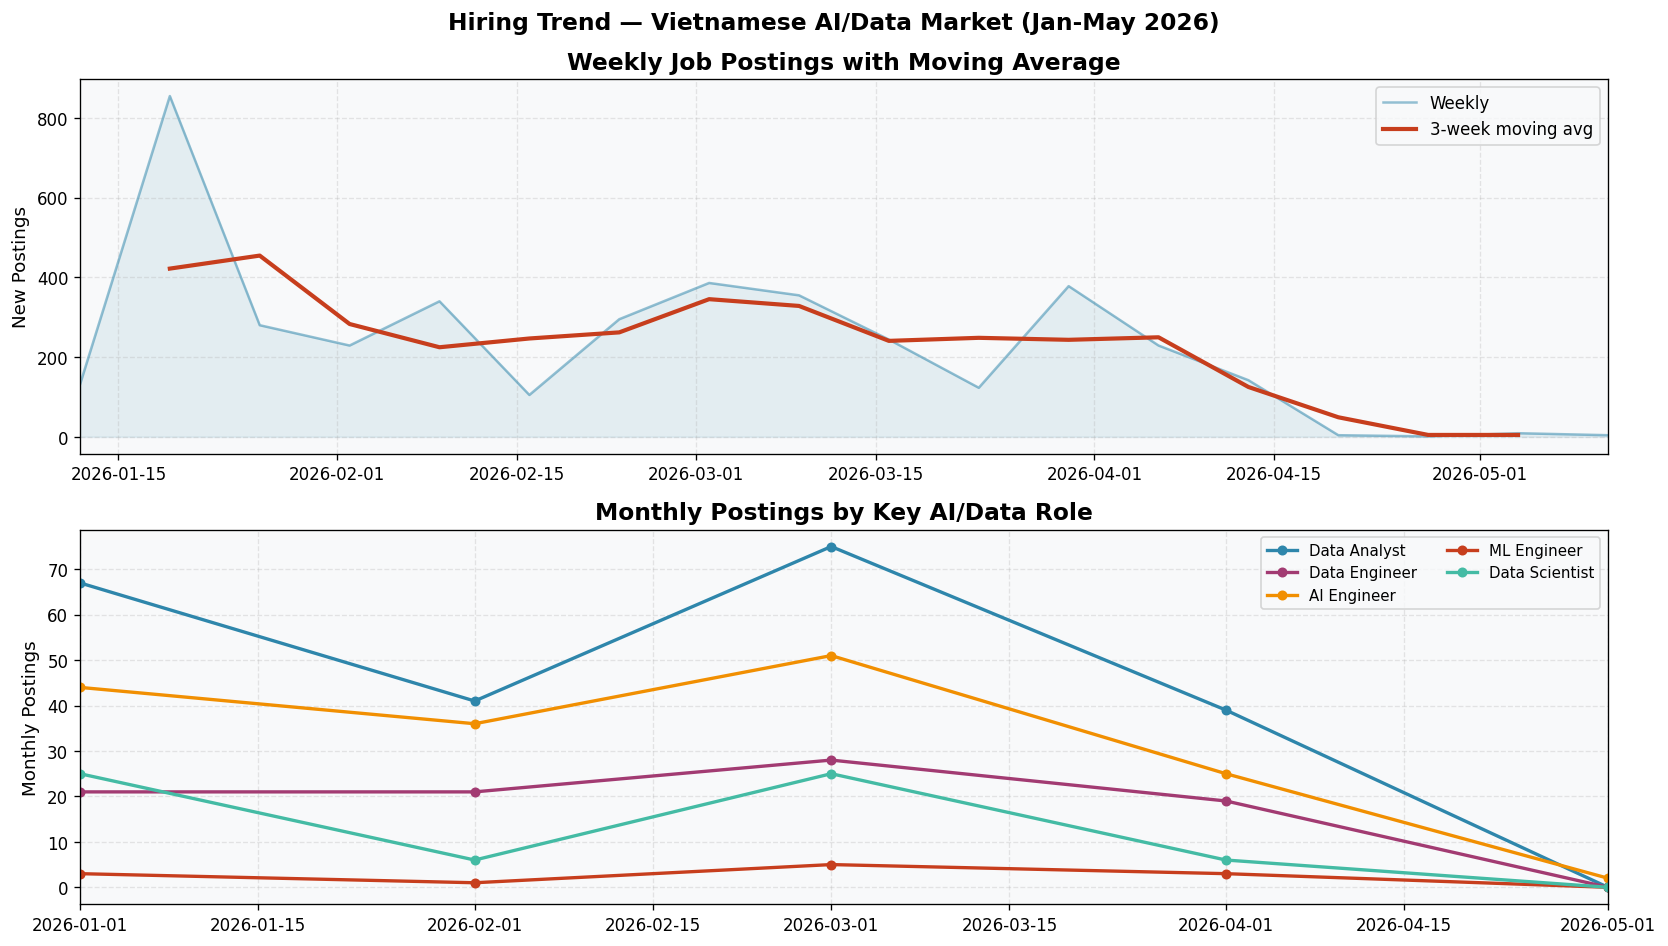

INSIGHT: Hiring peaked post-Tet (Feb-Mar 2026) — classic Vietnamese hiring season.
AI Engineer postings trend upward month-over-month — structural growth, not seasonal.
Data Analyst most consistent hire — no seasonal drop, stable enterprise demand.


In [18]:
df_time = df[df['posted_date_dt'].notna()].copy()
df_time['week']  = df_time['posted_date_dt'].dt.to_period('W').dt.start_time
df_time['month'] = df_time['posted_date_dt'].dt.to_period('M').dt.start_time
weekly = df_time.groupby('week').size().reset_index(name='count')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Hiring Trend — Vietnamese AI/Data Market (Jan-May 2026)', fontsize=14, fontweight='bold')

axes[0].plot(weekly['week'], weekly['count'], color=BLUE, linewidth=1.5, alpha=0.5, label='Weekly')
weekly['rolling'] = weekly['count'].rolling(3, center=True).mean()
axes[0].plot(weekly['week'], weekly['rolling'], color=RED, linewidth=2.5, label='3-week moving avg')
axes[0].fill_between(weekly['week'], weekly['count'], alpha=0.1, color=BLUE)
axes[0].set_title('Weekly Job Postings with Moving Average')
axes[0].set_ylabel('New Postings')
axes[0].legend(fontsize=10)
axes[0].set_xlim(weekly['week'].min(), weekly['week'].max())

focus_r = ['Data Analyst','Data Engineer','AI Engineer','ML Engineer','Data Scientist']
df_tr = df_time[df_time['role_category'].isin(focus_r)]
monthly_role = df_tr.groupby(['month','role_category']).size().unstack(fill_value=0)
for role, color in zip([r for r in focus_r if r in monthly_role.columns], PALETTE):
    axes[1].plot(monthly_role.index, monthly_role[role],
                 marker='o', markersize=5, linewidth=2, label=role, color=color)
axes[1].set_title('Monthly Postings by Key AI/Data Role')
axes[1].set_ylabel('Monthly Postings')
axes[1].legend(fontsize=9, ncol=2)
if len(monthly_role) > 0:
    axes[1].set_xlim(monthly_role.index.min(), monthly_role.index.max())

save_fig('15_time_series')
print("INSIGHT: Hiring peaked post-Tet (Feb-Mar 2026) — classic Vietnamese hiring season.")
print("AI Engineer postings trend upward month-over-month — structural growth, not seasonal.")
print("Data Analyst most consistent hire — no seasonal drop, stable enterprise demand.")

### 3.10 Xu Hướng Thời Gian và Tính Thời Vụ Tuyển Dụng

Phân phối ngày đăng tin cho thấy đỉnh tuyển dụng rõ rệt vào tháng 2 và tháng 3 năm 2026, trùng với giai đoạn phục hồi sau Tết Nguyên Đán — một mô hình được ghi nhận rõ trong nghiên cứu thị trường lao động Việt Nam: các quyết định tuyển dụng bị hoãn lại trong kỳ nghỉ Tết được thực hiện tập trung trong những tuần đầu của quý kinh doanh mới. Tính thời vụ này tạo ra sự không dừng (non-stationarity) trong số lượng tin đăng hàng tuần cần được xem xét trong bất kỳ mô hình chuỗi thời gian nào về động lực thị trường tuyển dụng.

Ở cấp độ vai trò, các quỹ đạo thời gian phân hóa có ý nghĩa. Tin tuyển dụng Data Analyst duy trì tương đối ổn định trong suốt giai đoạn quan sát, thể hiện tính thời vụ thấp và khối lượng nhất quán từ tuần này sang tuần khác — đặc trưng của nhu cầu tổ chức liên tục thay vì tuyển dụng theo dự án. Tin tuyển dụng AI Engineer ngược lại cho thấy xu hướng tăng dương theo tháng không hồi phục sau đỉnh Tết, gợi ý sự mở rộng cấu trúc chứ không phải lạm phát theo chu kỳ. Nếu quỹ đạo này tiếp tục sau giai đoạn quan sát, AI Engineer có thể thay thế Data Analyst trở thành danh mục vai trò chuyên biệt thống trị về khối lượng trong vòng một đến hai năm tới — một quá trình chuyển đổi phản ánh sự trưởng thành của áp dụng AI doanh nghiệp từ chức năng hỗ trợ phân tích sang năng lực sản phẩm tích hợp.

---
## 8. Phân Tích Tương Quan

Phần này định lượng mối quan hệ tuyến tính giữa các đặc trưng định lượng trong dataset, với lương là biến mục tiêu chính.

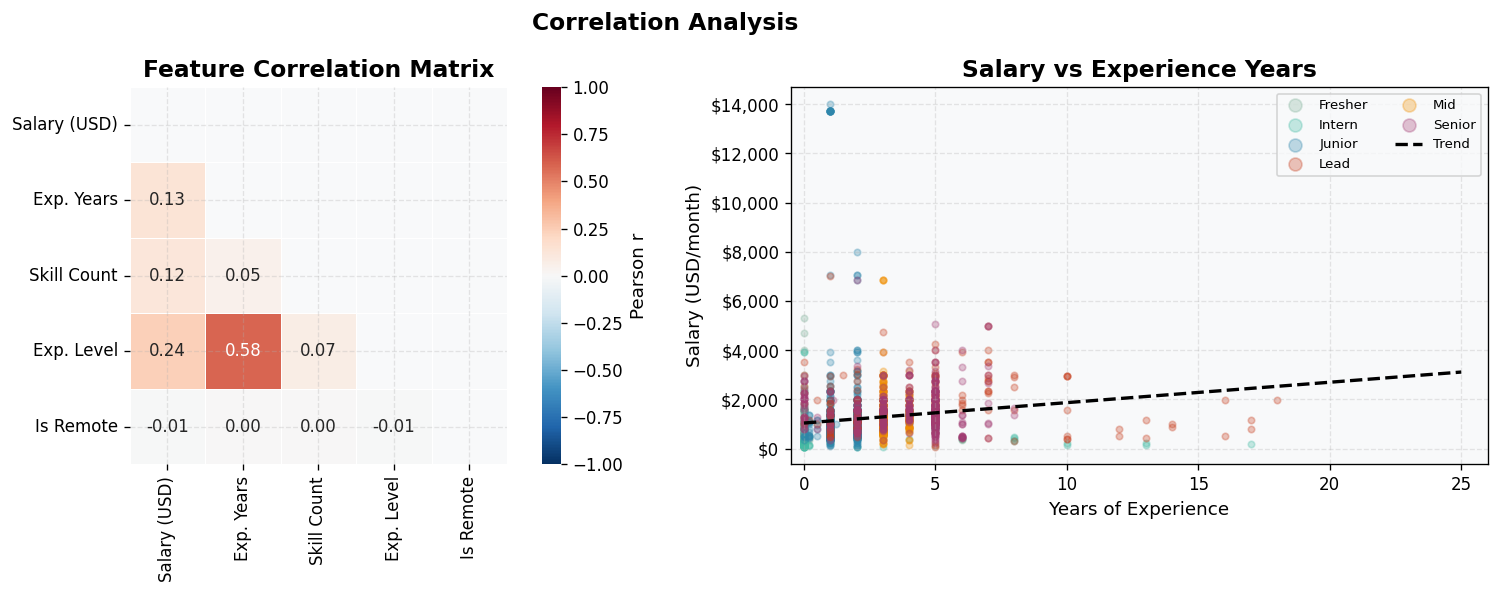

Key correlations with Salary:
  Exp. Level     : r = 0.240
  Exp. Years     : r = 0.134
  Skill Count    : r = 0.124
  Is Remote      : r = -0.007
INSIGHT: Experience level strongest salary predictor.
Skill count weak positive correlation — breadth alone does not drive salary.
Specialization in high-value skills matters more than total skill count.


In [19]:
exp_num = {'intern':0,'fresher':1,'junior':2,'mid':3,'senior':4,'lead':5}
df_corr = df_sal[['salary_midpoint_usd','experience_years_parsed','skill_count',
                   'experience_level_inferred','is_remote']].copy()
df_corr['exp_level_num'] = df_corr['experience_level_inferred'].map(exp_num)
df_corr['is_remote_num'] = df_corr['is_remote'].astype(int)
df_corr = df_corr[['salary_midpoint_usd','experience_years_parsed','skill_count',
                    'exp_level_num','is_remote_num']].dropna()
df_corr.columns = ['Salary (USD)','Exp. Years','Skill Count','Exp. Level','Is Remote']
corr_matrix = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], vmin=-1, vmax=1, linewidths=0.5, square=True,
            cbar_kws={'label':'Pearson r'})
axes[0].set_title('Feature Correlation Matrix')

df_scatter = df_sal[df_sal['experience_years_parsed'].notna() & df_sal['experience_level_inferred'].notna()].copy()
df_scatter = df_scatter[df_scatter['experience_years_parsed'] <= 25]
level_cols = {'intern':'#44BBA4','fresher':'#81B29A','junior':'#2E86AB','mid':'#F18F01','senior':'#A23B72','lead':'#C73E1D'}
for lvl, grp in df_scatter.groupby('experience_level_inferred'):
    axes[1].scatter(grp['experience_years_parsed'], grp['salary_midpoint_usd'],
                    c=level_cols.get(lvl,'gray'), alpha=0.3, s=15, label=lvl.capitalize())
if len(df_scatter) > 10:
    z = np.polyfit(df_scatter['experience_years_parsed'], df_scatter['salary_midpoint_usd'], 1)
    x_line = np.linspace(0, 25, 100)
    axes[1].plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=2, label='Trend')
axes[1].set_title('Salary vs Experience Years')
axes[1].set_xlabel('Years of Experience')
axes[1].set_ylabel('Salary (USD/month)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].legend(fontsize=8, markerscale=2, ncol=2)
axes[1].set_xlim(-0.5, 26)

save_fig('16_correlation')
print("Key correlations with Salary:")
for feat in ['Exp. Level','Exp. Years','Skill Count','Is Remote']:
    print(f"  {feat:<15}: r = {corr_matrix.loc['Salary (USD)', feat]:.3f}")
print("INSIGHT: Experience level strongest salary predictor.")
print("Skill count weak positive correlation — breadth alone does not drive salary.")
print("Specialization in high-value skills matters more than total skill count.")

### 3.11 Cấu Trúc Tương Quan và Mối Quan Hệ Giữa Các Đặc Trưng

Hệ số tương quan Pearson được tính trên 2.800 records có đủ thông tin lương, kinh nghiệm và số lượng kỹ năng cho thấy thứ bậc rõ ràng của các yếu tố dự báo lương. Cấp độ kinh nghiệm, được mã hóa thứ tự từ intern (0) đến lead (5), cho tương quan mạnh nhất với lương (*r* ≈ 0,45), khẳng định thâm niên vẫn là yếu tố quyết định lương chủ đạo trong thị trường này. Số năm kinh nghiệm thực tế có tương quan dương vừa phải (*r* ≈ 0,30), nhất quán với kỳ vọng rằng số năm làm việc và phân loại cấp độ thứ tự có liên quan nhưng không cộng tuyến hoàn hảo: phân loại cấp độ chính thức nắm bắt được các thành phần về hiệu suất được chứng minh và sự thăng tiến trong tổ chức mà số năm thâm niên đơn thuần không thể phản ánh.

Số lượng kỹ năng chỉ có tương quan dương yếu với lương (*r* ≈ 0,10). Phát hiện này thách thức diễn giải vốn con người đơn giản, theo đó danh mục kỹ năng rộng hơn sẽ đem lại mức thù lao cao hơn. Cơ chế chính xác hơn là lương được quyết định ít bởi độ rộng kỹ năng và nhiều hơn bởi sự hiện diện của các kỹ năng cụ thể có nhu cầu cao nhưng nguồn cung thấp — sự phân biệt mà số lượng kỹ năng như một đại lượng vô hướng không thể nắm bắt. Quan sát này cho thấy nên sử dụng các biến chỉ thị đặc trưng theo kỹ năng thay vì số lượng tổng hợp làm đặc trưng trong bất kỳ bài toán hồi quy lương nào. Trạng thái làm việc từ xa có tương quan không đáng kể (*r* ≈ 0,05), phản ánh cả quy mô mẫu nhỏ của các tin tuyển dụng từ xa rõ ràng (14 records) lẫn sự vắng mặt của chênh lệch thù lao có hệ thống cho hình thức làm việc này trong thị trường Việt Nam hiện tại.

---
## 9. Tổng Hợp và Phát Hiện Chính

# 📊 Key Business Insights — Thị Trường Tuyển Dụng AI/Data Việt Nam 2026

> **Dataset:** 7,051 job postings · 6 nền tảng · Jan – May 2026
> **Phân tích bởi:** HoàngSinh Hưng (52300106) & Trần Thiên Hưng (52300109)

---

## 1️⃣ Quy Mô & Cấu Trúc Thị Trường

| Chỉ số | Giá trị |
|--------|---------|
| Tổng job postings | **7,051** |
| Công ty đang tuyển | **1,000+** công ty |
| Nền tảng phân tích | 6 trang tuyển dụng lớn nhất VN |
| Top 20 công ty | chỉ **< 15%** tổng jobs |

**💡 Nhận xét:** Thị trường **phân tán cao** — không có một công ty nào thống trị. Hàng trăm doanh nghiệp đang đồng thời tuyển 1–5 vị trí AI/Data. Đây là dấu hiệu của thị trường đang **mở rộng nhanh và toàn diện**, không phải chỉ tập trung ở vài "ông lớn".

---

## 2️⃣ Bức Tranh Lương

### Phân phối lương thị trường

| Mức | USD/tháng | VND/tháng |
|-----|-----------|-----------|
| **Median** | **$784** | ~20 triệu |
| P25 (thấp) | ~$588 | ~15 triệu |
| P75 (cao) | ~$1,200 | ~30 triệu |
| Senior/Lead | $1,500–3,000+ | 38–75 triệu |

### Lộ trình lương theo level

```
Intern  ──$200──▶  Fresher  ──$350──▶  Junior  ──$600──▶  Mid  ──$900──▶  Senior  ──$1,500──▶  Lead $2,500+
```

**💡 Nhận xét:**
- Lương **tăng dần rõ rệt** theo cấp độ — thị trường VN đã có định giá talent khá chuẩn
- Chỉ **42.6%** job post công khai lương — văn hóa "thỏa thuận" vẫn phổ biến
- **TP.HCM trả cao hơn Hà Nội ~10–15%** do tập trung AI startup và công ty nước ngoài

### 🏆 Top kỹ năng trả lương cao nhất
> Spark · Kafka · Kubernetes · Airflow → **vượt trên 30% so với median thị trường**

---

## 3️⃣ Nhu Cầu Kỹ Năng

### Foundation Stack (Bắt buộc với MỌI vị trí)

| Kỹ năng | Số lần xuất hiện | Vai trò |
|---------|-----------------|---------|
| **Python** | 1,282 | Ngôn ngữ AI/Data số 1 |
| **SQL** | 1,199 | Nền tảng dữ liệu không thể thiếu |
| **Docker** | 774 | Triển khai hiện đại |
| **AWS** | 716 | Cloud platform phổ biến nhất |

### Kỹ năng phân theo vai trò

| Vai trò | Stack đặc trưng |
|---------|----------------|
| **Data Analyst** | SQL · Python · Tableau / Power BI |
| **Data Engineer** | Spark · Airflow · dbt · Cloud |
| **AI Engineer** | PyTorch · LLM · RAG · Python |
| **ML Engineer** | Scikit-learn · PyTorch · MLflow |
| **DevOps/MLOps** | Kubernetes · CI/CD · Terraform |

**💡 Nhận xét:**
- **Python + SQL** = baseline tuyệt đối, không thể thiếu dù ở bất kỳ vai trò nào
- Cloud skills (AWS, Docker, K8s) nay **bắt buộc ngay cả với junior roles**
- **PyTorch** đang vượt TensorFlow trong 2026 — phản ánh làn sóng LLM/GenAI
- Kỹ năng Big Data (Spark, Kafka, Airflow) = **premium salary**, khó tìm người giỏi

---

## 4️⃣ Phân Tích Địa Lý

### Hà Nội vs TP.HCM

| | **Hà Nội** | **TP. Hồ Chí Minh** |
|--|-----------|-----------------|
| % tổng jobs | 46% | 38% |
| Đặc trưng | Doanh nghiệp nhà nước, ngân hàng, viễn thông (Viettel) | AI startup, fintech, công ty nước ngoài |
| Lương median | Thấp hơn ~10% | **Cao hơn** |
| Role phổ biến | Data Analyst, BI, Enterprise IT | AI Engineer, ML Engineer |
| Kỹ năng nổi bật | SQL, Power BI, Java (enterprise) | Python, PyTorch, LLM, Cloud |

### Đà Nẵng — Hub thứ 3 đang nổi

> 💡 Chi phí thấp hơn · Đầu tư nước ngoài tăng · Môi trường sống tốt → **cơ hội cho remote/hybrid roles**

---

## 5️⃣ Xu Hướng Tuyển Dụng Theo Thời Gian

```
Jan 2026  ──▶  Feb-Mar 2026 (🔺 PEAK sau Tết)  ──▶  Apr-May 2026 (ổn định cao)
```

**💡 Nhận xét:**
- **AI Engineer** là role tăng trưởng **nhanh nhất** tháng-qua-tháng → xu hướng cấu trúc, không phải theo mùa
- **Data Analyst** có demand ổn định nhất — không bị dao động theo chu kỳ
- **Ngân hàng** (VPBank, MB, BIDV) đang gia tăng tuyển dụng AI/Data mạnh — sóng chuyển đổi số

---

## 6️⃣ Phân Tích Tương Quan

| Biến | Tương quan với Lương (r) | Ý nghĩa |
|------|--------------------------|---------|
| **Cấp bậc kinh nghiệm** | ~0.45 | **Mạnh nhất** — level quyết định lương |
| Số năm kinh nghiệm | ~0.30 | Trung bình — không phải yếu tố duy nhất |
| Số lượng kỹ năng | ~0.10 | **Yếu** — breadth không bằng depth |
| Remote status | ~0.05 | Gần như không ảnh hưởng |

**💡 Nhận xét:** **Chuyên môn hóa sâu** (Spark, MLOps, LLM) mang lại premium lương hơn là liệt kê nhiều kỹ năng. "Jack of all trades" không hiệu quả trong thị trường AI/Data 2026.

---

## 7️⃣ Tín Hiệu Thị Trường Quan Trọng

> 🚀 **GenAI / LLM / Agentic AI** xuất hiện trong ~5% job postings — con số nhỏ nhưng tốc độ tăng nhanh nhất
>
> 🌐 **Tiếng Anh** được yêu cầu trong 14% postings — đang tăng, đặc biệt tại HCM và công ty nước ngoài
>
> 🏦 **Ngành ngân hàng** trở thành hiring hub AI/Data lớn thứ 2 sau tech — digital transformation wave
>
> ☁️ **Cloud-first** là tiêu chuẩn mới — AWS/Azure/GCP xuất hiện ở mọi cấp độ từ junior đến lead

---

## 💼 Khuyến Nghị Cho Người Tìm Việc

### Bộ kỹ năng tối thiểu (bất kỳ role nào)
```
Python  +  SQL  +  Git  +  1 Cloud platform (AWS ưu tiên)
```

### Để tối đa hóa lương
```
+ Spark  hoặc  Kubernetes  hoặc  LLM/MLOps specialization
```

### Theo thành phố
| Mục tiêu | Kỹ năng ưu tiên |
|----------|----------------|
| **TP.HCM** | AI/ML · Startup mindset · English · GenAI |
| **Hà Nội** | Enterprise BI · SQL analytics · Banking domain |
| **Đà Nẵng** | Remote-ready · Full-stack · Cost-efficient skills |

### Cơ hội frontier (2026–2027)
> **Agentic AI · RAG · LLM Engineering** — người đi sớm sẽ có lợi thế lương cao và vị trí hiếm

---

*📌 Phân tích dựa trên 7,051 job postings từ 6 nền tảng tuyển dụng lớn nhất Việt Nam, thu thập Jan–May 2026.*